# Week 7: Linear Family Experiments on the Shared UHPC Dataset

**Target:** UHPC 28-day compressive strength (`cs_28d`)  
**Model family:** Linear Family only  
**Dataset policy:** shared semantic-recoded 50 percent UHPC dataset  
**Preprocessing contract:** 33 raw predictors become **60 transformed model columns**.

This notebook is updated to use the corrected shared dataset from Week 7 onward. Week 6 remains a preprocessing-strategy exploration, but Week 7+ uses the shared representation so our results are comparable with the rest of the project.

## Executive Summary

- The shared modeling file contains **2073 rows**.
- The split is **1449 train / 311 validation / 313 test** rows.
- The preprocessing pipeline fits only on training rows and produces **60 model-input columns**: 24 numeric, 5 one-hot categorical, and 4 target-encoded categorical source columns.
- The validation-selected baseline is **Bayesian Ridge**.
- Test performance for the selected model: **RMSE 20.935 MPa**, **MAE 16.563 MPa**, **R2 0.689**.
- Numeric VIF is not severe: max VIF is **3.809**, and no numeric feature is above 5.

## 1. Why the Dataset Setup Changed

Earlier Week 7 work still referenced our older S1 import path and our own one-hot/missing-indicator setup. That was not ideal for cross-team comparison because different preprocessing strategies create different numbers of model inputs.

The corrected setup uses a neutral shared folder:

`data/processed/shared_strategies/uhpc_semantic_50/`

The important modeling files are:

- `uhpc_semantic_50_modeling.csv` for Week 7 row-mixed experiments.
- `uhpc_semantic_50_publication_ready.csv` for Week 8 and Week 9 publication-aware workflows.

The shared semantic dataset is not already scaled or encoded. Scaling, imputation, one-hot encoding, and target encoding still happen inside training pipelines.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "reports" / "tables").exists() and (candidate / "src" / "s1_linear").exists():
            return candidate
    raise RuntimeError("Could not find the S1_Linear project root.")


PROJECT_ROOT = find_project_root()
TABLES = PROJECT_ROOT / "reports" / "tables"
FIGURES = PROJECT_ROOT / "reports" / "figures" / "week07"
DATA = PROJECT_ROOT / "data" / "processed" / "shared_strategies" / "uhpc_semantic_50"


def load_table(name: str) -> pd.DataFrame:
    return pd.read_csv(TABLES / name)


def show_figure(name: str, width: int = 950) -> None:
    path = FIGURES / name
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        print(f"Missing figure: {path}")


def rounded(df: pd.DataFrame, digits: int = 3) -> pd.DataFrame:
    return df.round(digits)

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Data-to-Design-ML/S1_Linear


In [2]:
source = pd.read_csv(DATA / "uhpc_semantic_50_source.csv")
modeling = pd.read_csv(DATA / "uhpc_semantic_50_modeling.csv")
publication_ready = pd.read_csv(DATA / "uhpc_semantic_50_publication_ready.csv")

pd.DataFrame([
    {"file": "uhpc_semantic_50_source.csv", "rows": len(source), "columns": source.shape[1], "has_publication": "paper_reference" in source.columns},
    {"file": "uhpc_semantic_50_modeling.csv", "rows": len(modeling), "columns": modeling.shape[1], "has_publication": "paper_reference" in modeling.columns},
    {"file": "uhpc_semantic_50_publication_ready.csv", "rows": len(publication_ready), "columns": publication_ready.shape[1], "has_publication": "paper_reference" in publication_ready.columns},
])

,file,rows,columns,has_publication
0,uhpc_semantic_50_source.csv,2073,35,False
1,uhpc_semantic_50_modeling.csv,2073,34,False
2,uhpc_semantic_50_publication_ready.csv,2073,35,True


## 2. Preprocessing Contract and Leakage Control

The shared preprocessing contract is fixed from Week 7 onward:

- Numeric predictors: median imputation plus `StandardScaler`.
- Low-cardinality categorical predictors: `OneHotEncoder(handle_unknown='ignore')`.
- Higher-cardinality categorical predictors: `TargetEncoder(cv=5)`, then scaling for the target-encoded columns.
- No target values are used for numeric imputation or scaling.
- All preprocessing is inside the model pipeline, so cross-validation folds fit their own preprocessing on their own training fold.

The standalone transformed split files are only for inspection. Model selection uses raw split CSVs plus pipelines to avoid leakage.

In [3]:
split_summary = load_table("week07_semantic_50_split_summary.csv")
preprocessing_summary = load_table("week07_semantic_50_preprocessing_summary.csv")
column_contract = load_table("week07_shared_column_contract.csv")
feature_names = load_table("week07_semantic_50_transformed_feature_names.csv")

print("Transformed feature count:", len(feature_names))
display(rounded(split_summary))
display(preprocessing_summary)
display(column_contract.groupby("shared_feature_group").agg(
    source_columns=("source_column", "count"),
    missing_cells_train=("missing_count_train", "sum"),
).reset_index())

Transformed feature count: 60


,policy,split_strategy,total_rows,train_rows,validation_rows,test_rows,train_percentage,validation_percentage,test_percentage,train_target_mean,validation_target_mean,test_target_mean,train_target_std,validation_target_std,test_target_std,feature_hash_groups_crossing_splits,random_state
0,shared_semantic_recoding_50_percent,feature_hash_grouped,2073,1449,311,313,69.899,15.002,15.099,150.348,148.756,150.903,35.779,37.853,37.614,0,42


,policy,raw_predictors,numeric_predictors,categorical_predictors,transformed_predictors,numeric_imputer,numeric_missing_indicators,numeric_scaler,one_hot_predictors,target_encoded_predictors,categorical_missing_value,categorical_encoder,preprocessor_fit_rows,remaining_nan_train,remaining_nan_validation,remaining_nan_test
0,shared_semantic_recoding_50_percent,33,24,9,60,median,False,StandardScaler,5,4,preserved_for_shared_strategy,OneHotEncoder(handle_unknown='ignore') + TargetEncoder(cv=5),1449,0,0,0


,shared_feature_group,source_columns,missing_cells_train
0,numeric_scaled,24,301
1,one_hot_encoded,5,0
2,target_encoded_scaled,4,0


## 3. Models and Selection Rule

I used four Linear Family models:

- **OLS** as an unregularized reference.
- **Elastic Net** as the main regularized sparse/stable linear model.
- **Bayesian Ridge** as a probabilistic regularized linear model.
- **Polynomial Ridge** as the fourth model, replacing separate Ridge/Lasso because Elastic Net already covers the Ridge/Lasso family idea.

Hyperparameters are selected using training-only grouped cross-validation. The final baseline is selected by validation RMSE, then reported once on the unchanged test split.

In [4]:
baseline_metrics = load_table("week07_baseline_metrics.csv")
best_model = load_table("week07_best_baseline_model.csv")
tuning_summary = load_table("week07_tuning_summary.csv")

validation_metrics = baseline_metrics.query("split == 'validation'").sort_values("RMSE")
test_metrics = baseline_metrics.query("split == 'test'").sort_values("RMSE")

display(tuning_summary[["model", "tuned", "candidate_count", "best_cv_RMSE", "best_parameters"]].round(3))
display(rounded(validation_metrics[["model", "MAE", "RMSE", "R2", "Bias", "MedianAE"]]))
display(rounded(test_metrics[["model", "MAE", "RMSE", "R2", "Bias", "MedianAE"]]))
display(rounded(best_model))

,model,tuned,candidate_count,best_cv_RMSE,best_parameters
0,OLS,False,1,NaN,{}
1,Elastic Net,True,25,23.970,"{""model__alpha"": 0.01, ""model__l1_ratio"": 0.3}"
2,Bayesian Ridge,True,9,24.030,"{""model__alpha_1"": 1e-05, ""model__lambda_1"": 1e-07}"
3,Polynomial Ridge,True,5,19.832,"{""model__alpha"": 100.0, ""poly__degree"": 2}"


,model,MAE,RMSE,R2,Bias,MedianAE
7,Bayesian Ridge,16.991,21.743,0.669,-1.276,13.957
4,Elastic Net,16.978,21.748,0.669,-1.230,13.766
1,OLS,16.975,21.963,0.662,-0.950,13.416
10,Polynomial Ridge,30.645,343.344,-81.537,-19.820,7.984


,model,MAE,RMSE,R2,Bias,MedianAE
11,Polynomial Ridge,11.144,15.509,0.829,1.413,7.722
5,Elastic Net,16.542,20.908,0.690,2.769,13.918
8,Bayesian Ridge,16.563,20.935,0.689,2.660,13.810
2,OLS,16.557,21.087,0.685,3.183,13.680


,selection_rule,best_model,validation_RMSE,validation_MAE,validation_R2,test_RMSE,test_MAE,test_R2
0,lowest_validation_RMSE,Bayesian Ridge,21.743,16.991,0.669,20.935,16.563,0.689


## 4. Baseline Interpretation

The selected model is **Bayesian Ridge**. Its validation RMSE is **21.743 MPa**, and its test RMSE is **20.935 MPa**.

This is a usable linear baseline for a heterogeneous literature-style UHPC dataset, but the model is not perfect. The results should be interpreted as a baseline under the shared 60-column preprocessing contract, not as a final production model.

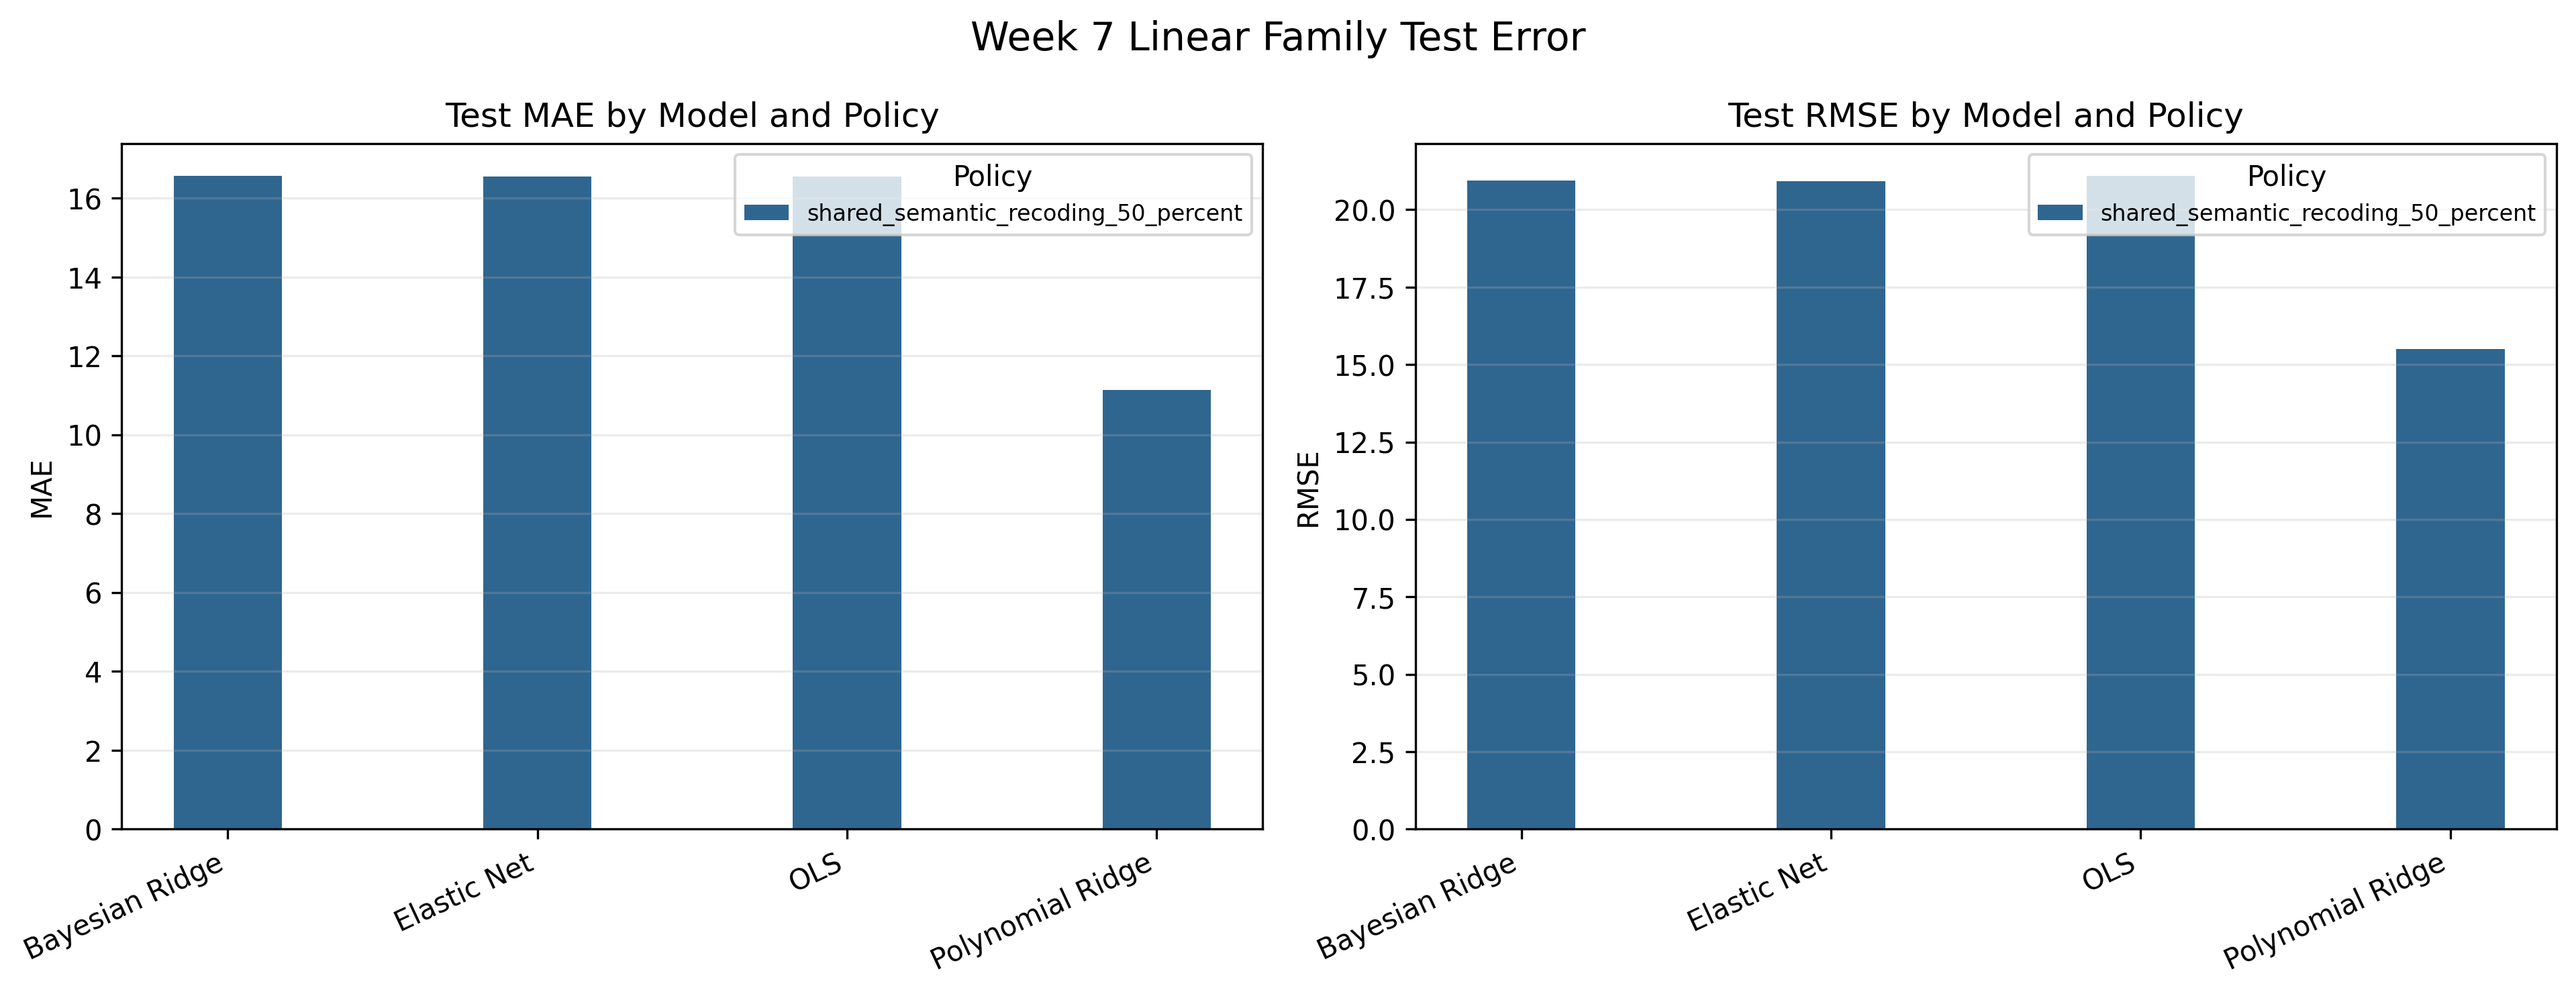

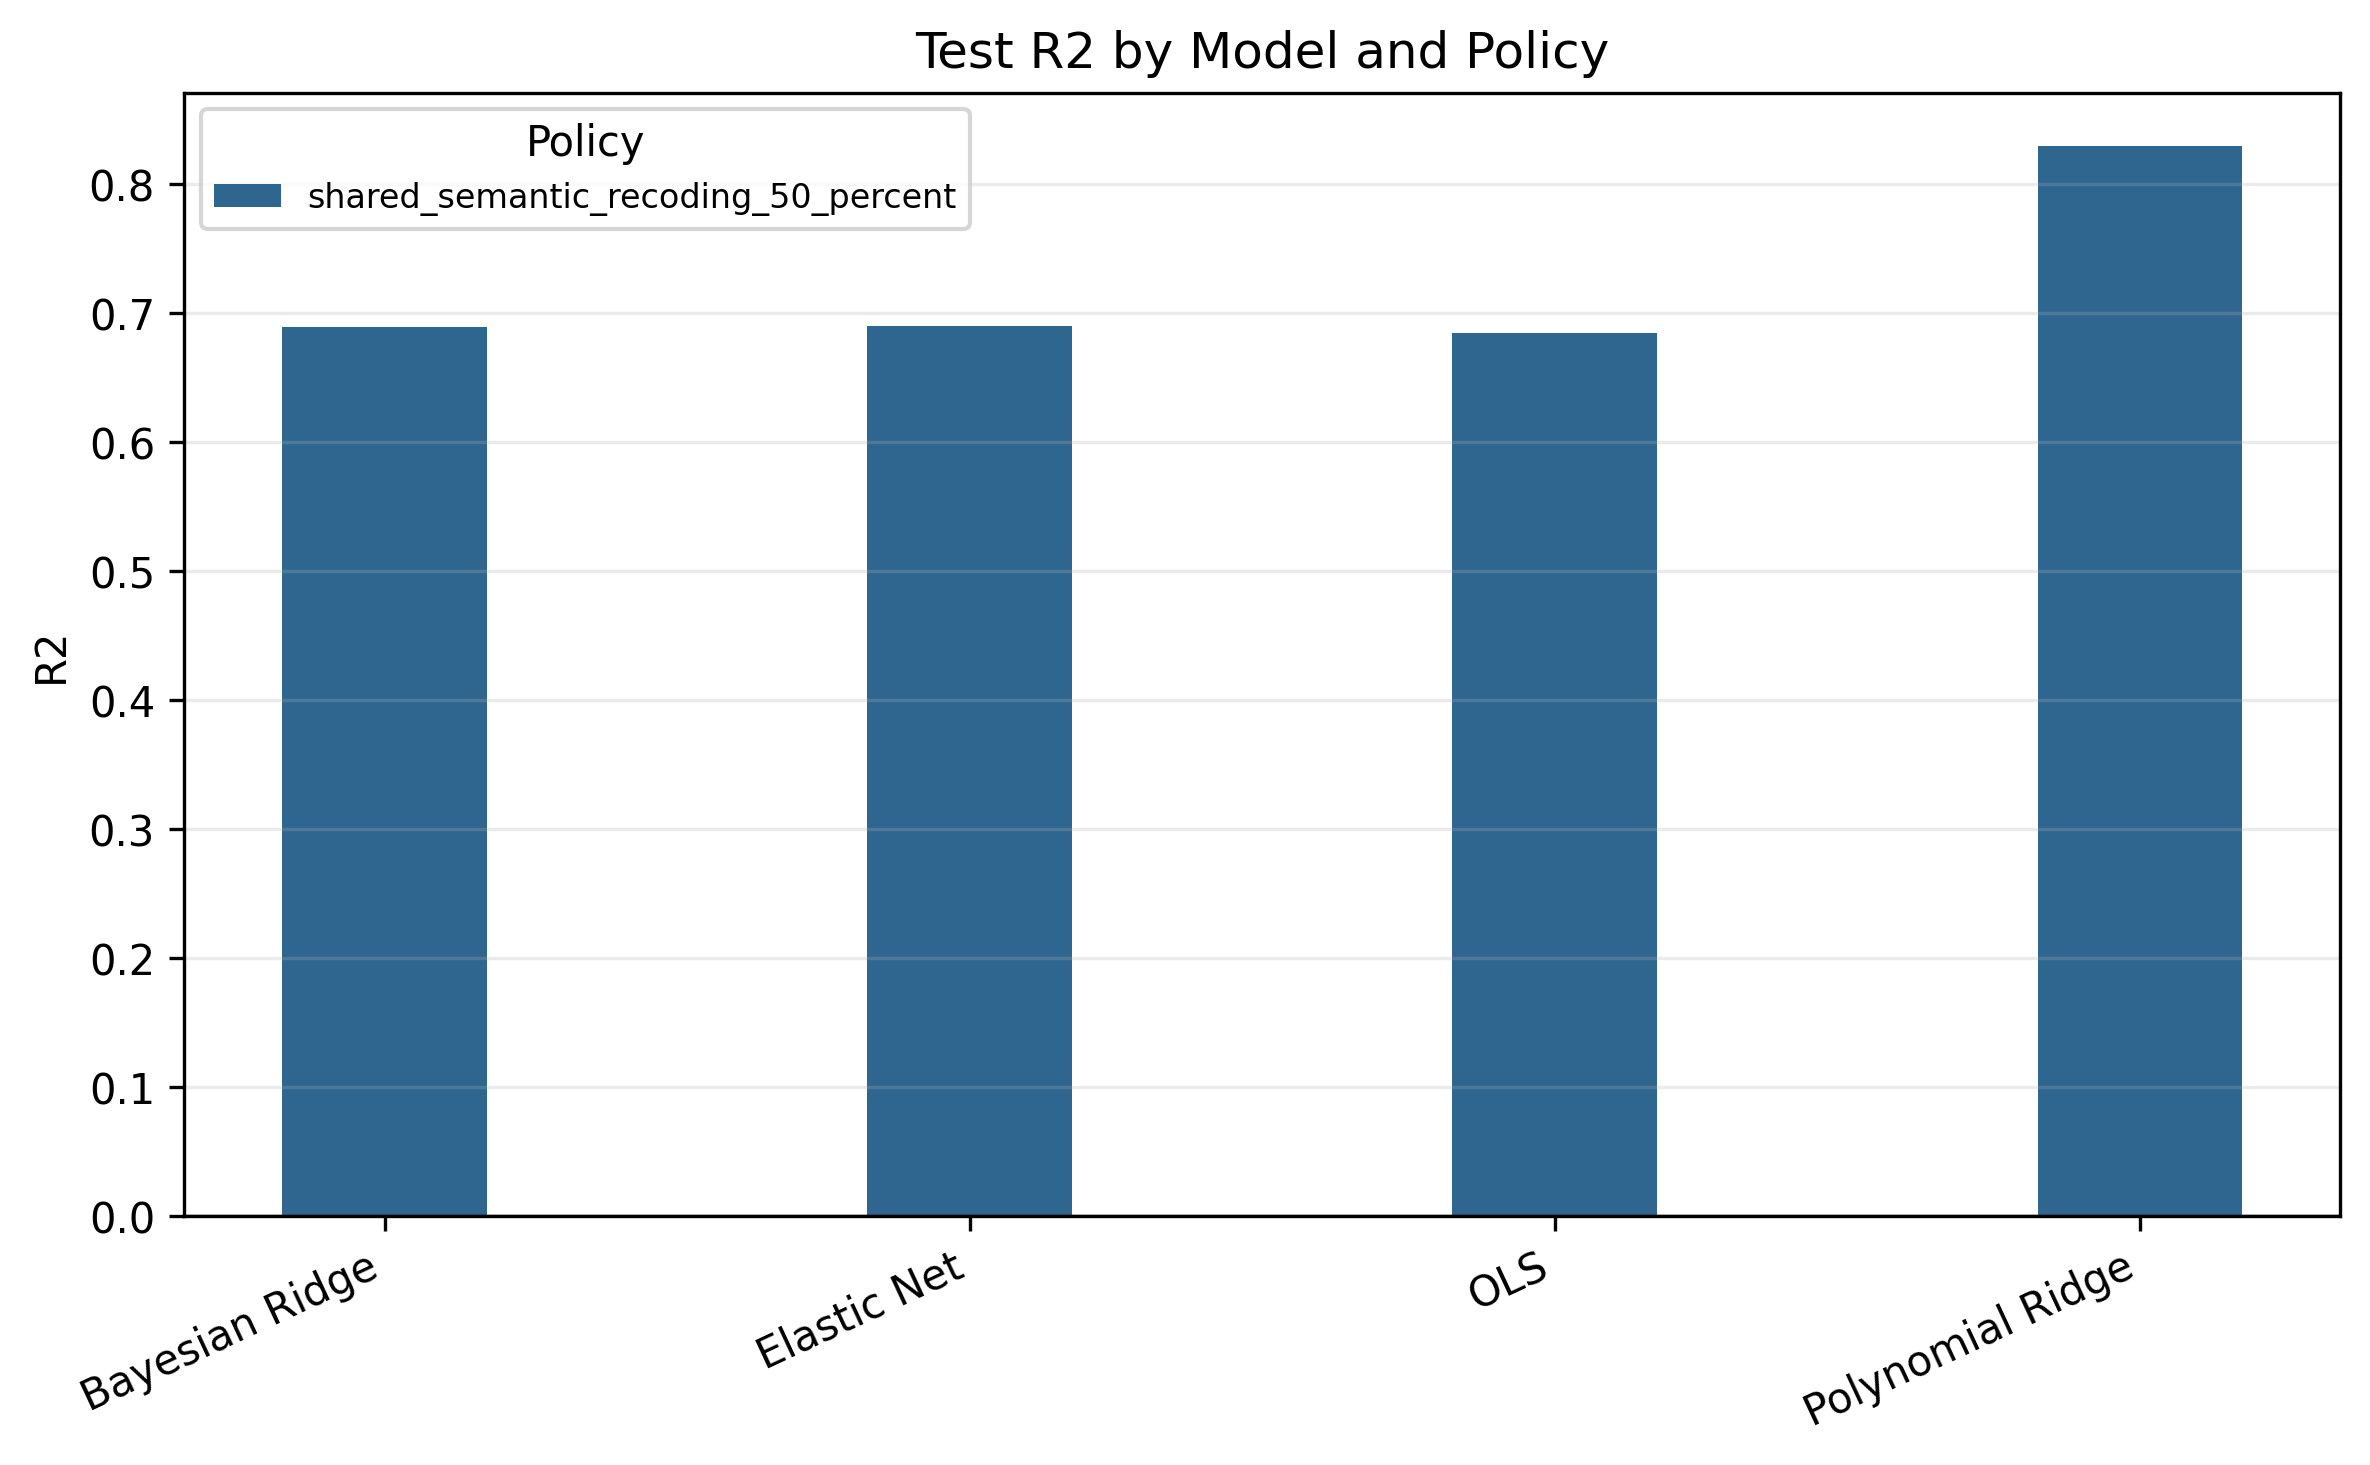

In [5]:
show_figure("week07_metrics_comparison.png", width=1100)
show_figure("week07_r2_comparison.png", width=850)

## 5. Prediction and Residual Behavior

The prediction and residual plots help explain where the selected model behaves well or poorly. In UHPC data, large residuals can come from special curing regimes, unusual binder systems, fiber systems, or publication-specific reporting/testing differences.

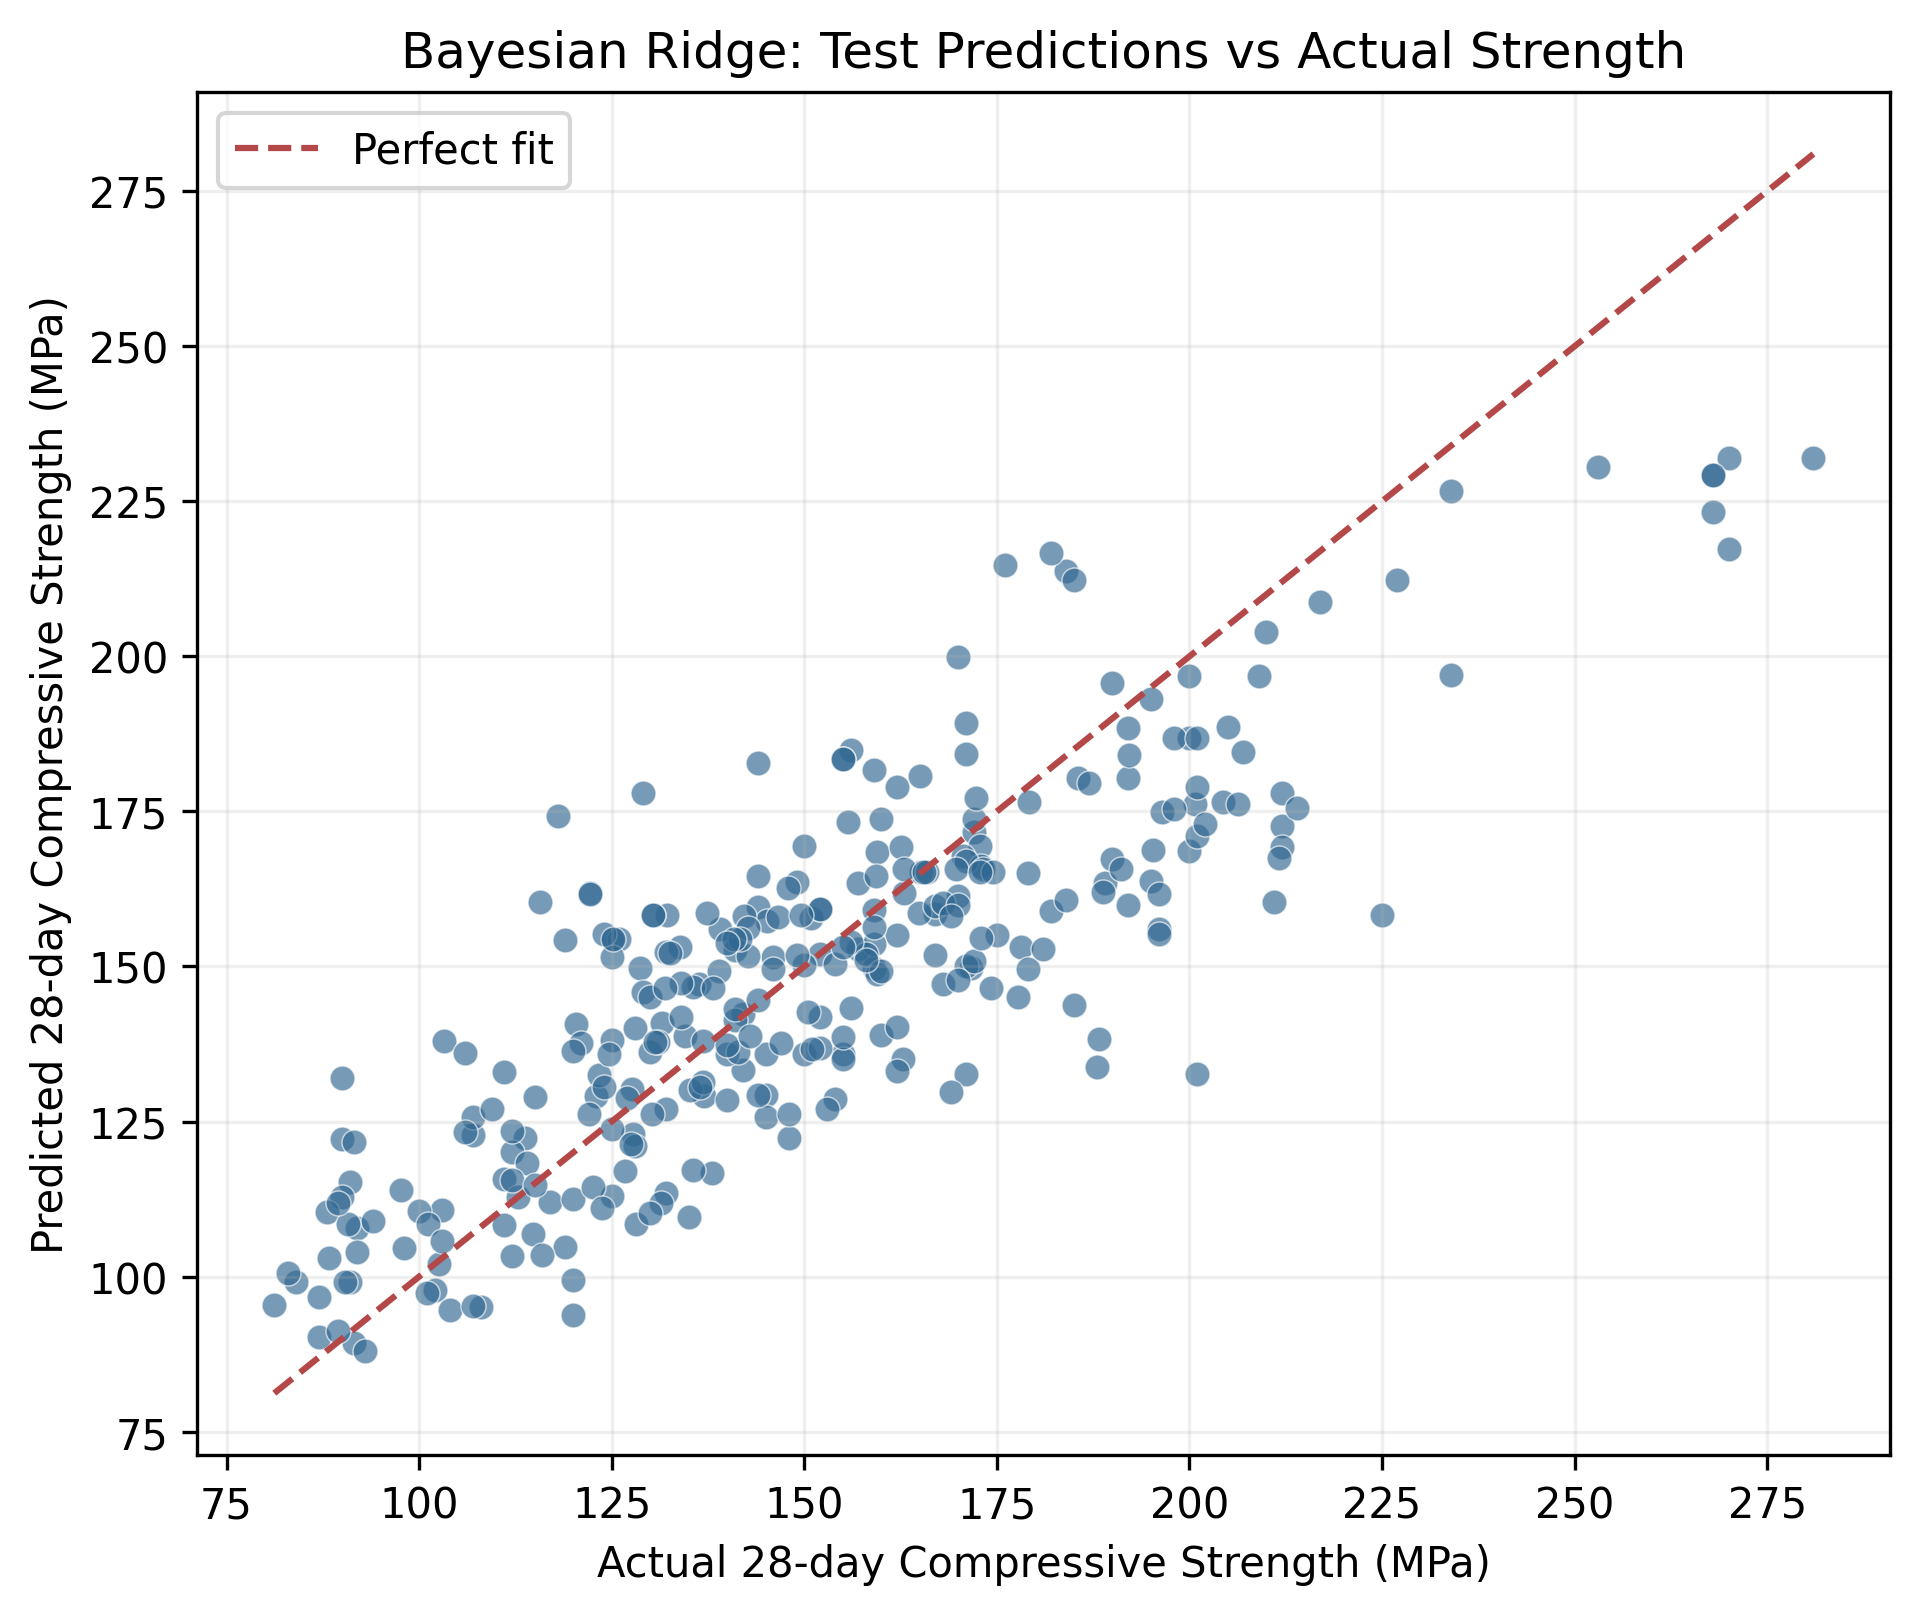

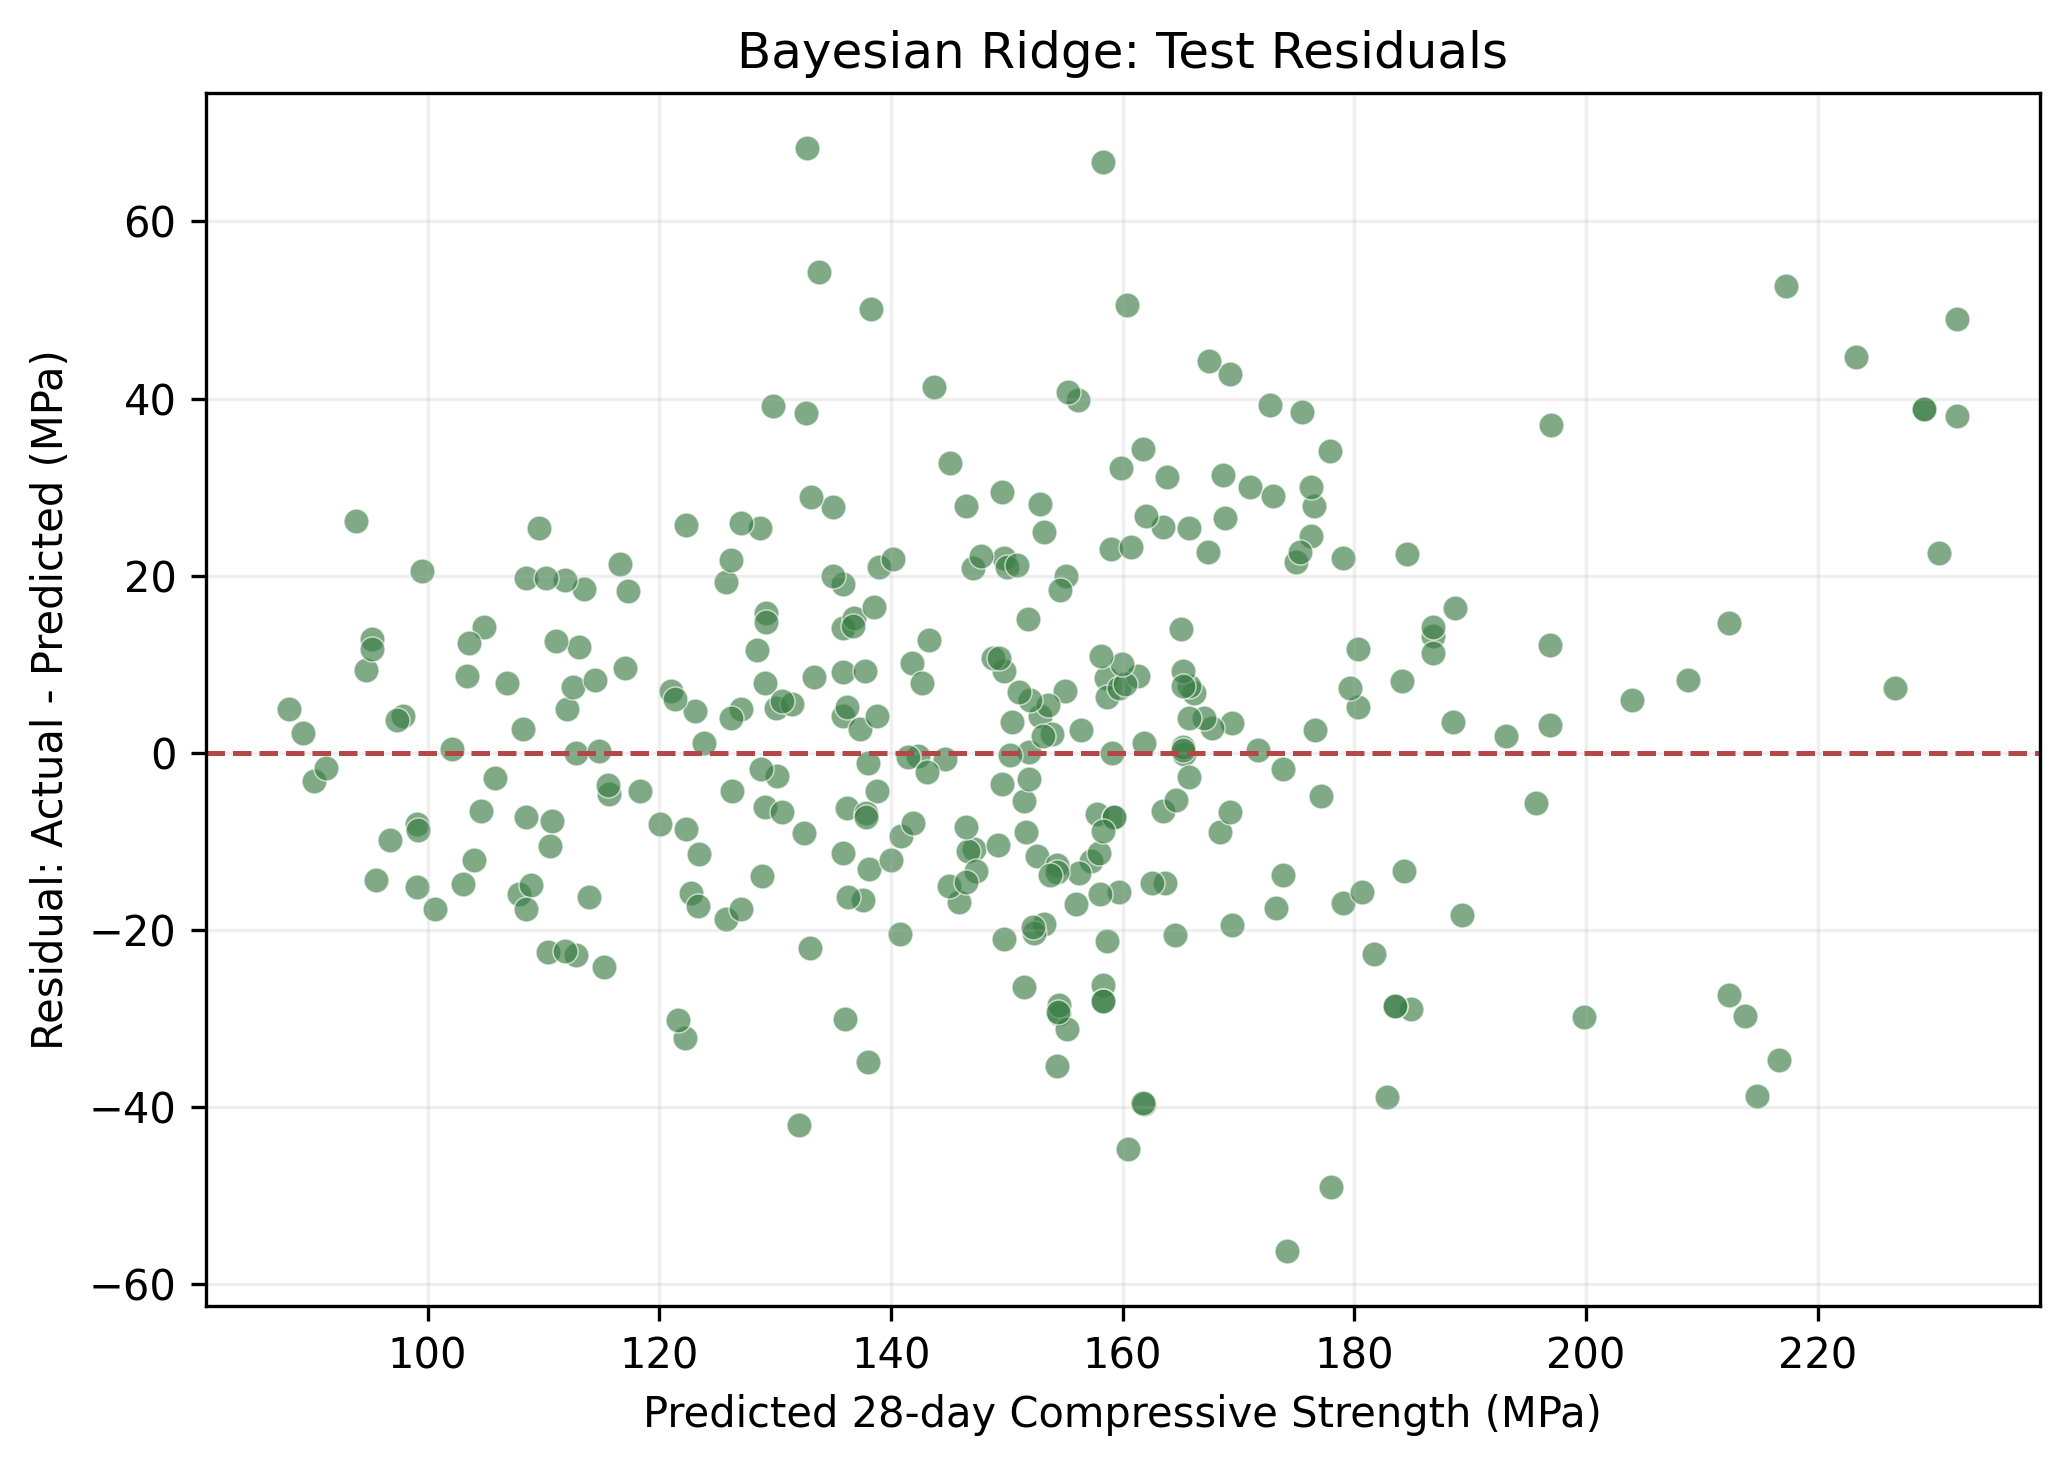

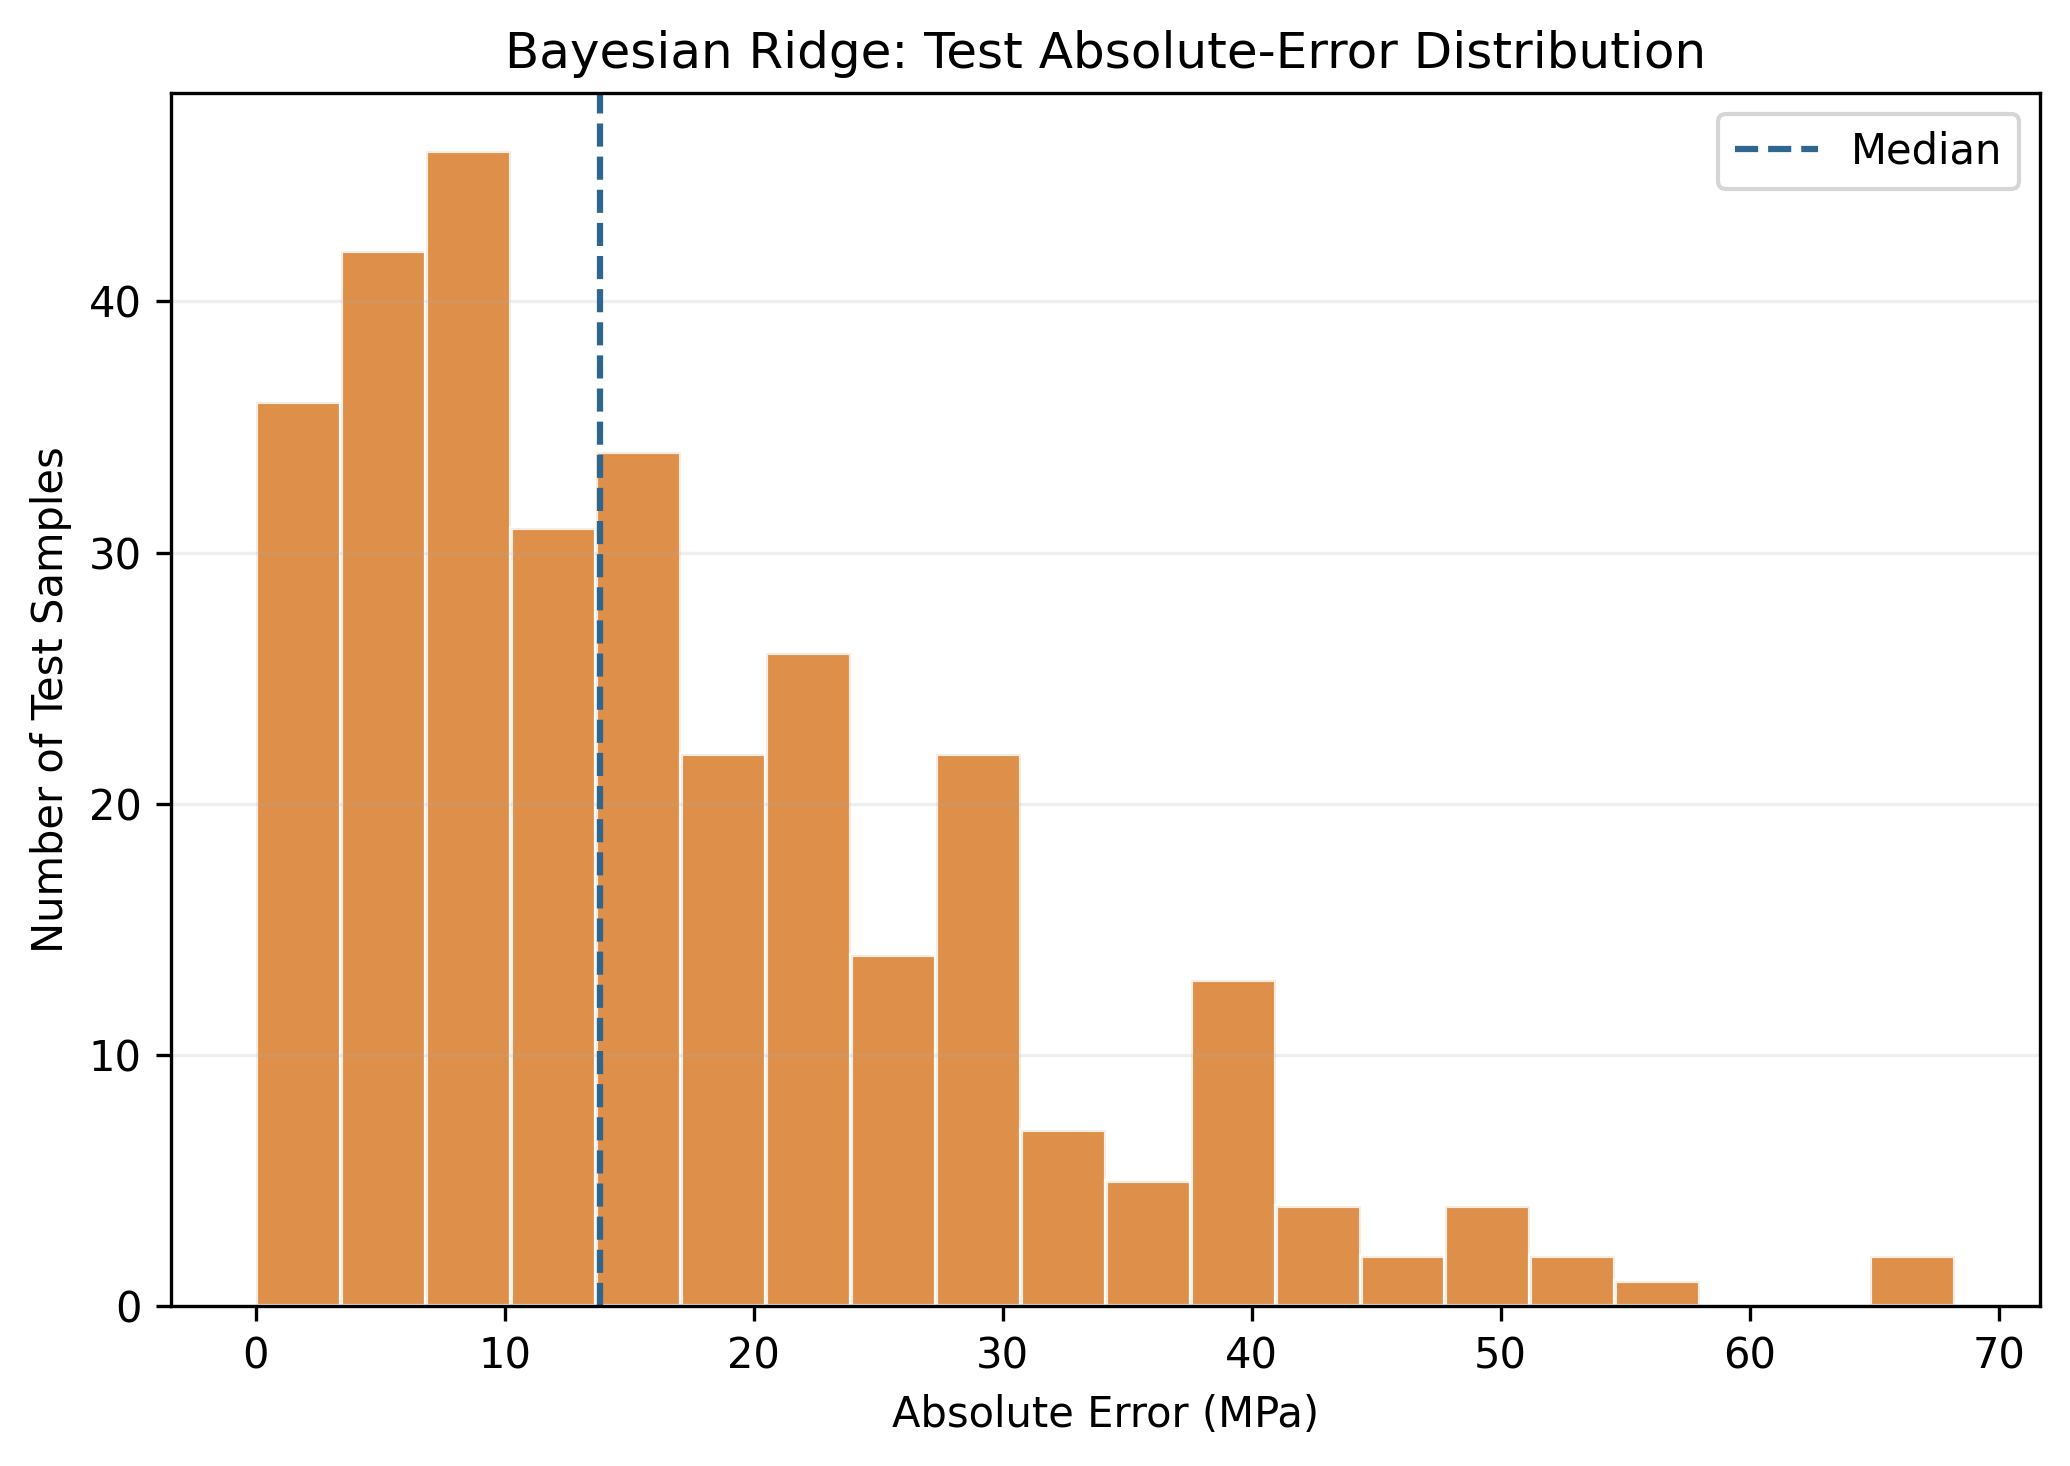

,Actual,Predicted,Residual,AbsoluteError
count,313.000,313.000,313.000,313.000
mean,150.903,148.243,2.660,16.563
std,37.614,29.529,20.798,12.825
min,81.200,88.039,-56.224,0.009
25%,125.000,128.804,-12.069,6.850
50%,147.900,150.052,2.848,13.810
75%,172.000,165.247,15.209,22.824
max,281.000,232.006,68.260,68.260


In [6]:
baseline_predictions = load_table("week07_baseline_predictions.csv")
best_name = best_model.loc[0, "best_model"]
best_predictions = baseline_predictions.query("split == 'test' and model == @best_name")

show_figure("week07_selected_baseline_predicted_vs_actual.png", width=750)
show_figure("week07_selected_baseline_residuals.png", width=850)
show_figure("week07_selected_baseline_error_distribution.png", width=850)
display(rounded(best_predictions[["Actual", "Predicted", "Residual", "AbsoluteError"]].describe()))

## 6. VIF Diagnostic

VIF is a diagnostic for numeric multicollinearity and OLS coefficient stability. It is not a model-performance metric and it does not use the target.

,policy,max_vif,median_vif,number_features_vif_above_5,number_features_vif_above_10,number_inf_vif
0,shared_semantic_recoding_50_percent,3.809,1.6,0,0,0


,policy,feature,VIF,R2_against_other_features,interpretation
0,shared_semantic_recoding_50_percent,cement,3.809,0.737,acceptable
1,shared_semantic_recoding_50_percent,sand,3.170,0.685,acceptable
2,shared_semantic_recoding_50_percent,fiber1_diameter,3.110,0.678,acceptable
3,shared_semantic_recoding_50_percent,fly_ash,2.886,0.654,acceptable
4,shared_semantic_recoding_50_percent,fiber1_length,2.371,0.578,acceptable
5,shared_semantic_recoding_50_percent,ggbfs,2.061,0.515,acceptable
6,shared_semantic_recoding_50_percent,water,2.015,0.504,acceptable
7,shared_semantic_recoding_50_percent,fiber1_amount,1.943,0.485,acceptable
8,shared_semantic_recoding_50_percent,quartz_powder,1.916,0.478,acceptable
9,shared_semantic_recoding_50_percent,glass_powder,1.835,0.455,acceptable


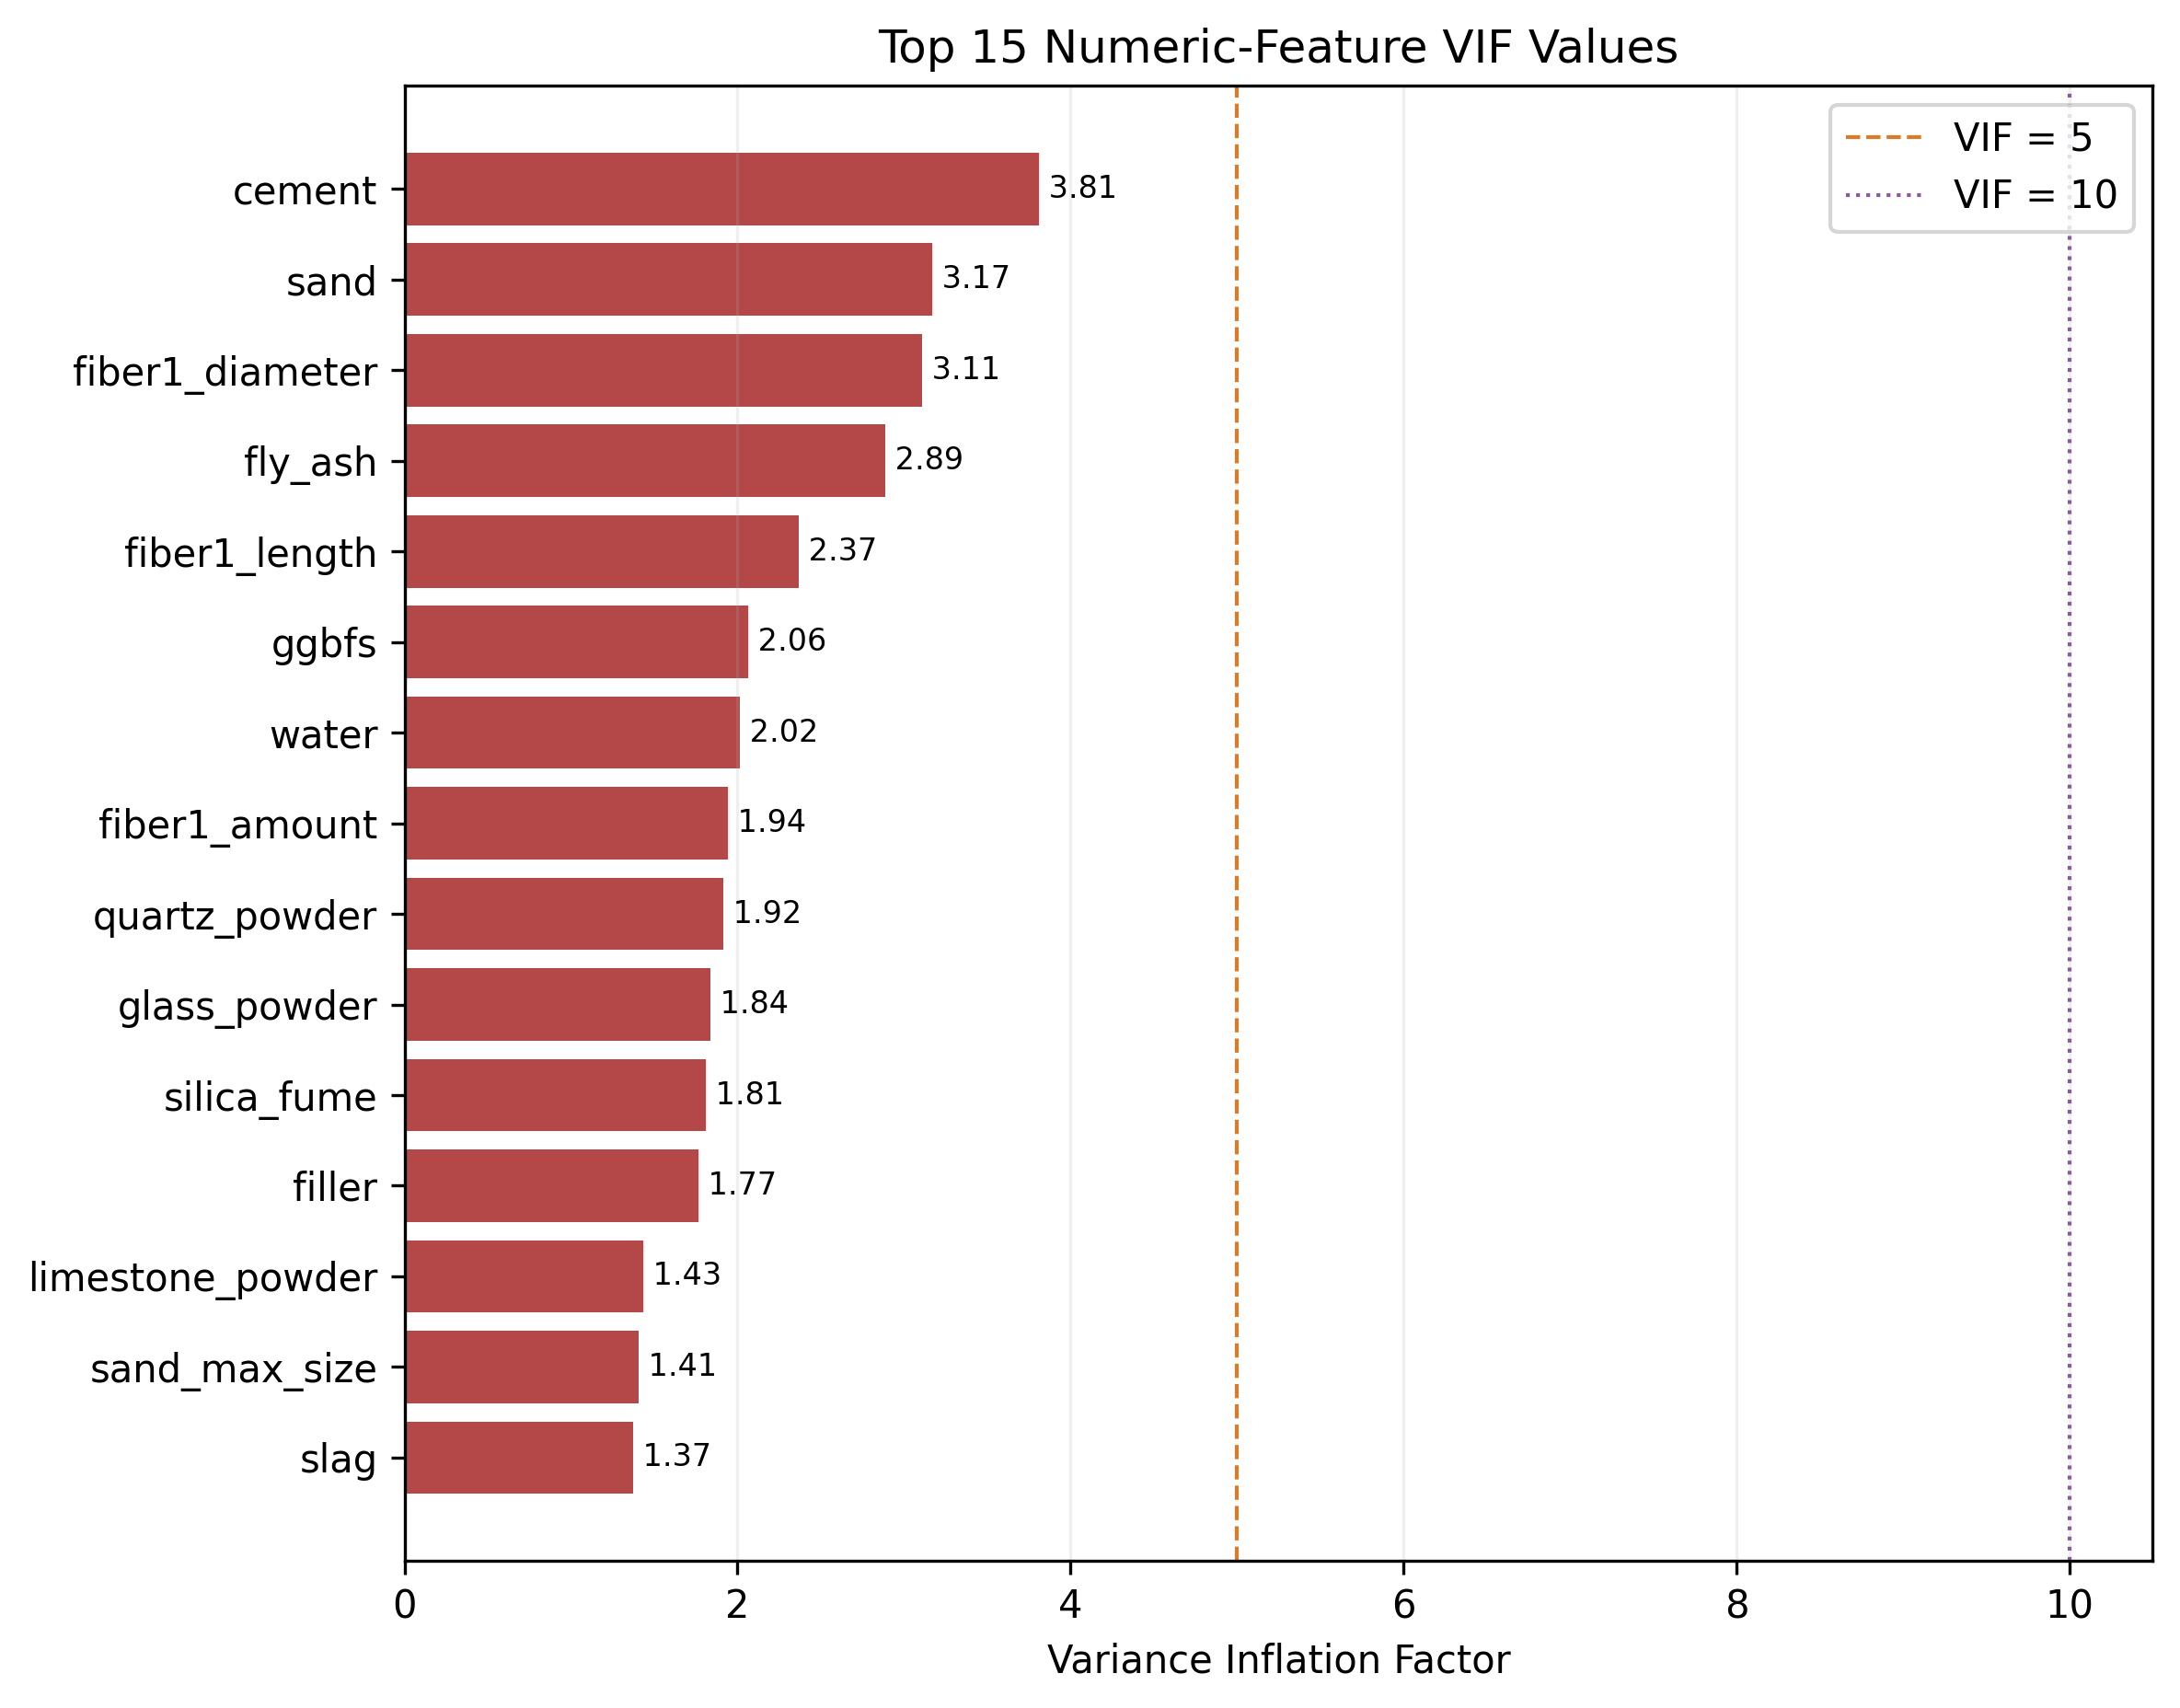

In [7]:
vif_table = load_table("week07_numeric_vif.csv")
vif_summary = load_table("week07_numeric_vif_summary.csv")

display(rounded(vif_summary))
display(rounded(vif_table.head(15)))
show_figure("week07_top_vif.png", width=900)

The current numeric feature set has max VIF **3.809** and median VIF **1.600**. There are no numeric predictors above 5 or 10, so severe numeric multicollinearity is not the main limitation here.

## 7. Error Analysis by Strength, Curing, and Fiber Groups

These analyses use the selected baseline predictions and ask whether errors are concentrated in interpretable UHPC subgroups.

,strength_bin,n_rows,MAE,RMSE,Bias,MedianAE,ActualMean,PredictedMean
0,>180,62,27.971,31.943,24.830,27.597,207.270,182.440
1,<=120,63,14.591,18.535,-9.680,12.441,102.886,112.566
2,150-180,86,13.310,16.729,5.609,10.093,164.002,158.393
3,120-150,102,13.589,16.628,-5.680,11.998,135.255,140.935


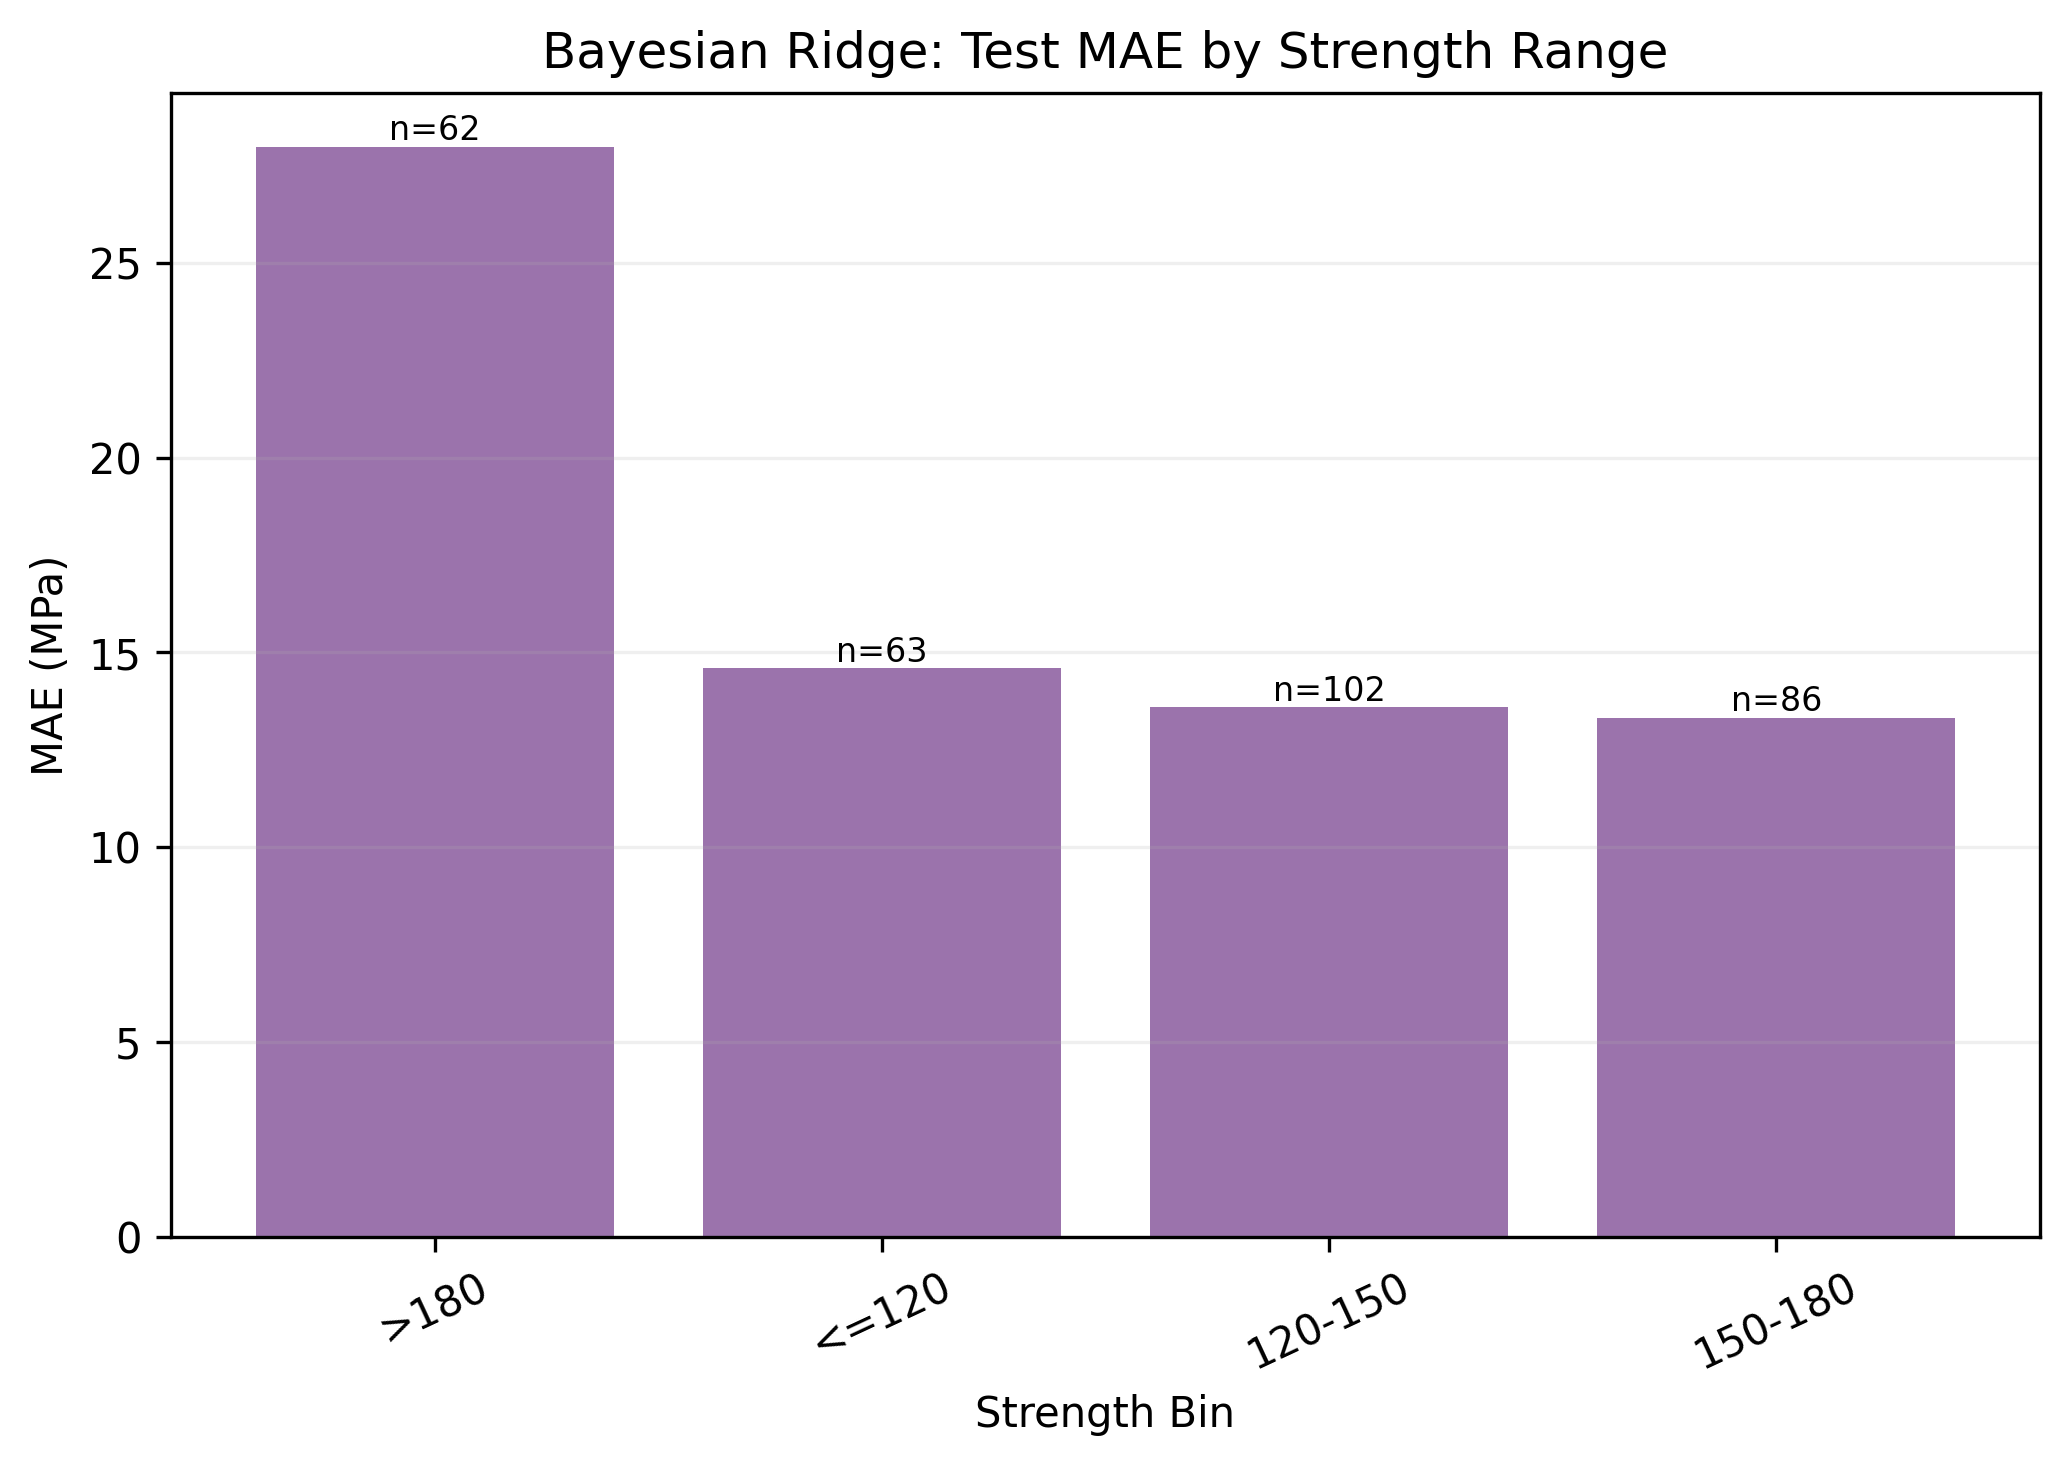

,curing_group,n_rows,MAE,RMSE,Bias,MedianAE,ActualMean,PredictedMean
0,autoclave,12,29.690,32.769,10.657,32.228,217.333,206.676
1,water,19,24.667,26.651,2.656,22.195,144.284,141.628
2,steam,62,17.169,22.104,3.978,14.288,168.809,164.830
3,heat,34,17.737,21.944,-0.822,13.629,168.882,169.704
4,standard_or_normal,181,14.577,18.721,2.660,11.634,139.369,136.709
5,other,5,10.635,11.773,-9.167,8.712,89.884,99.051


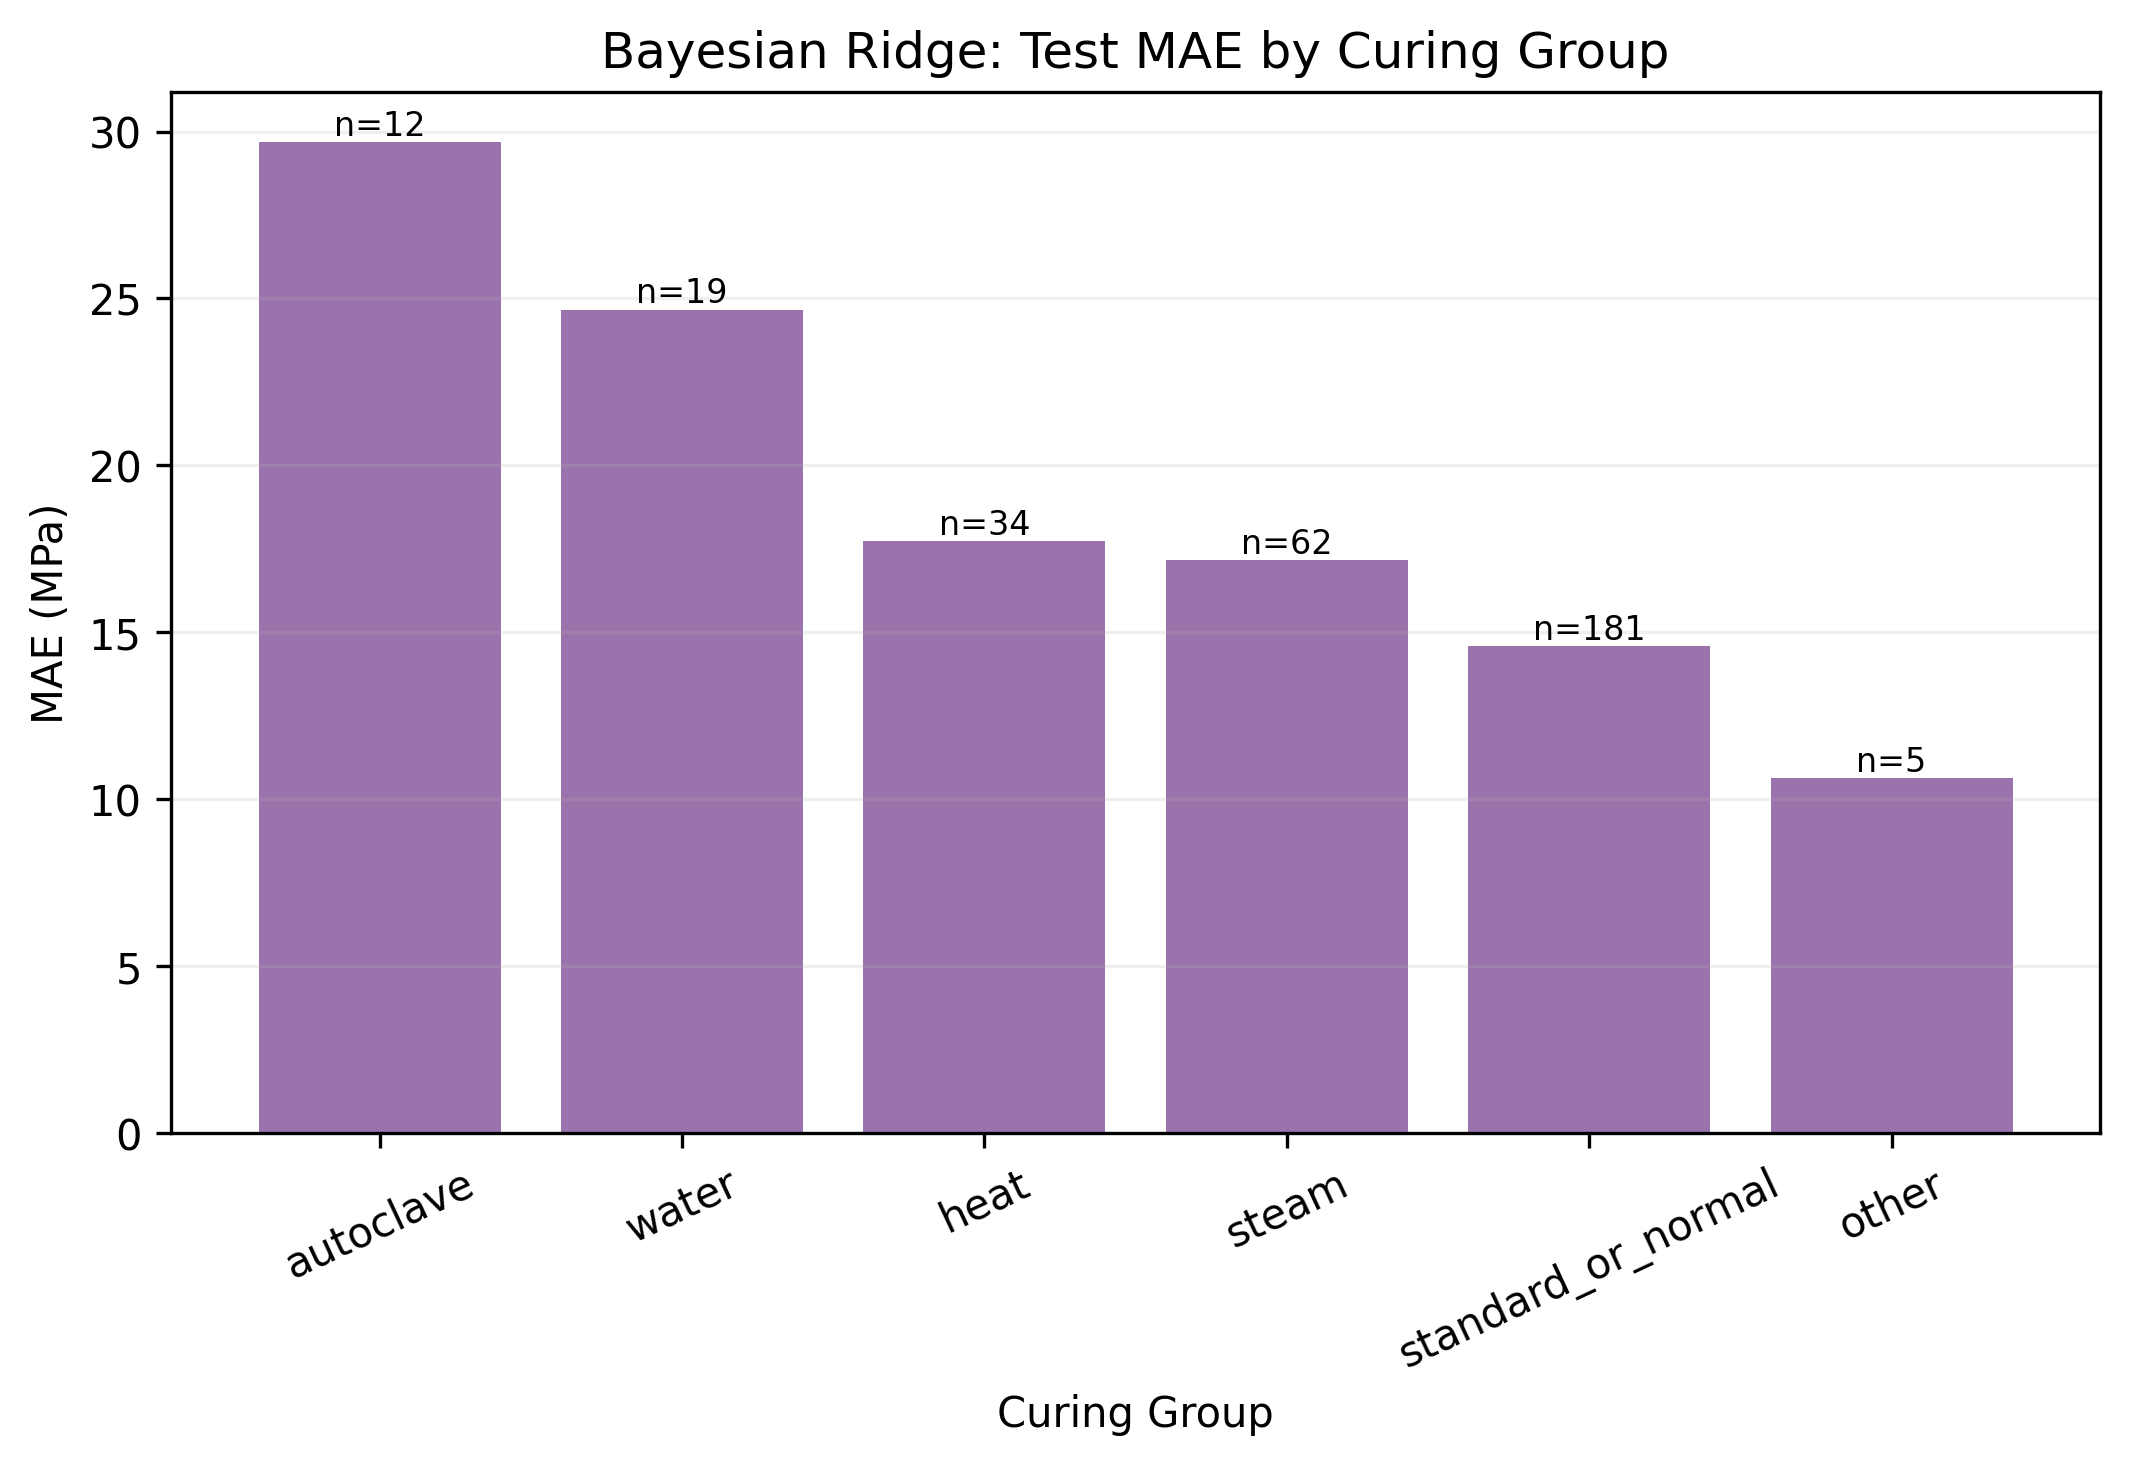

,fiber_group,n_rows,MAE,RMSE,Bias,MedianAE,ActualMean,PredictedMean
0,fiber_used,222,17.013,21.316,4.435,14.170,158.866,154.432
1,no_fiber_reported,91,15.465,19.974,-1.668,13.451,131.477,133.145


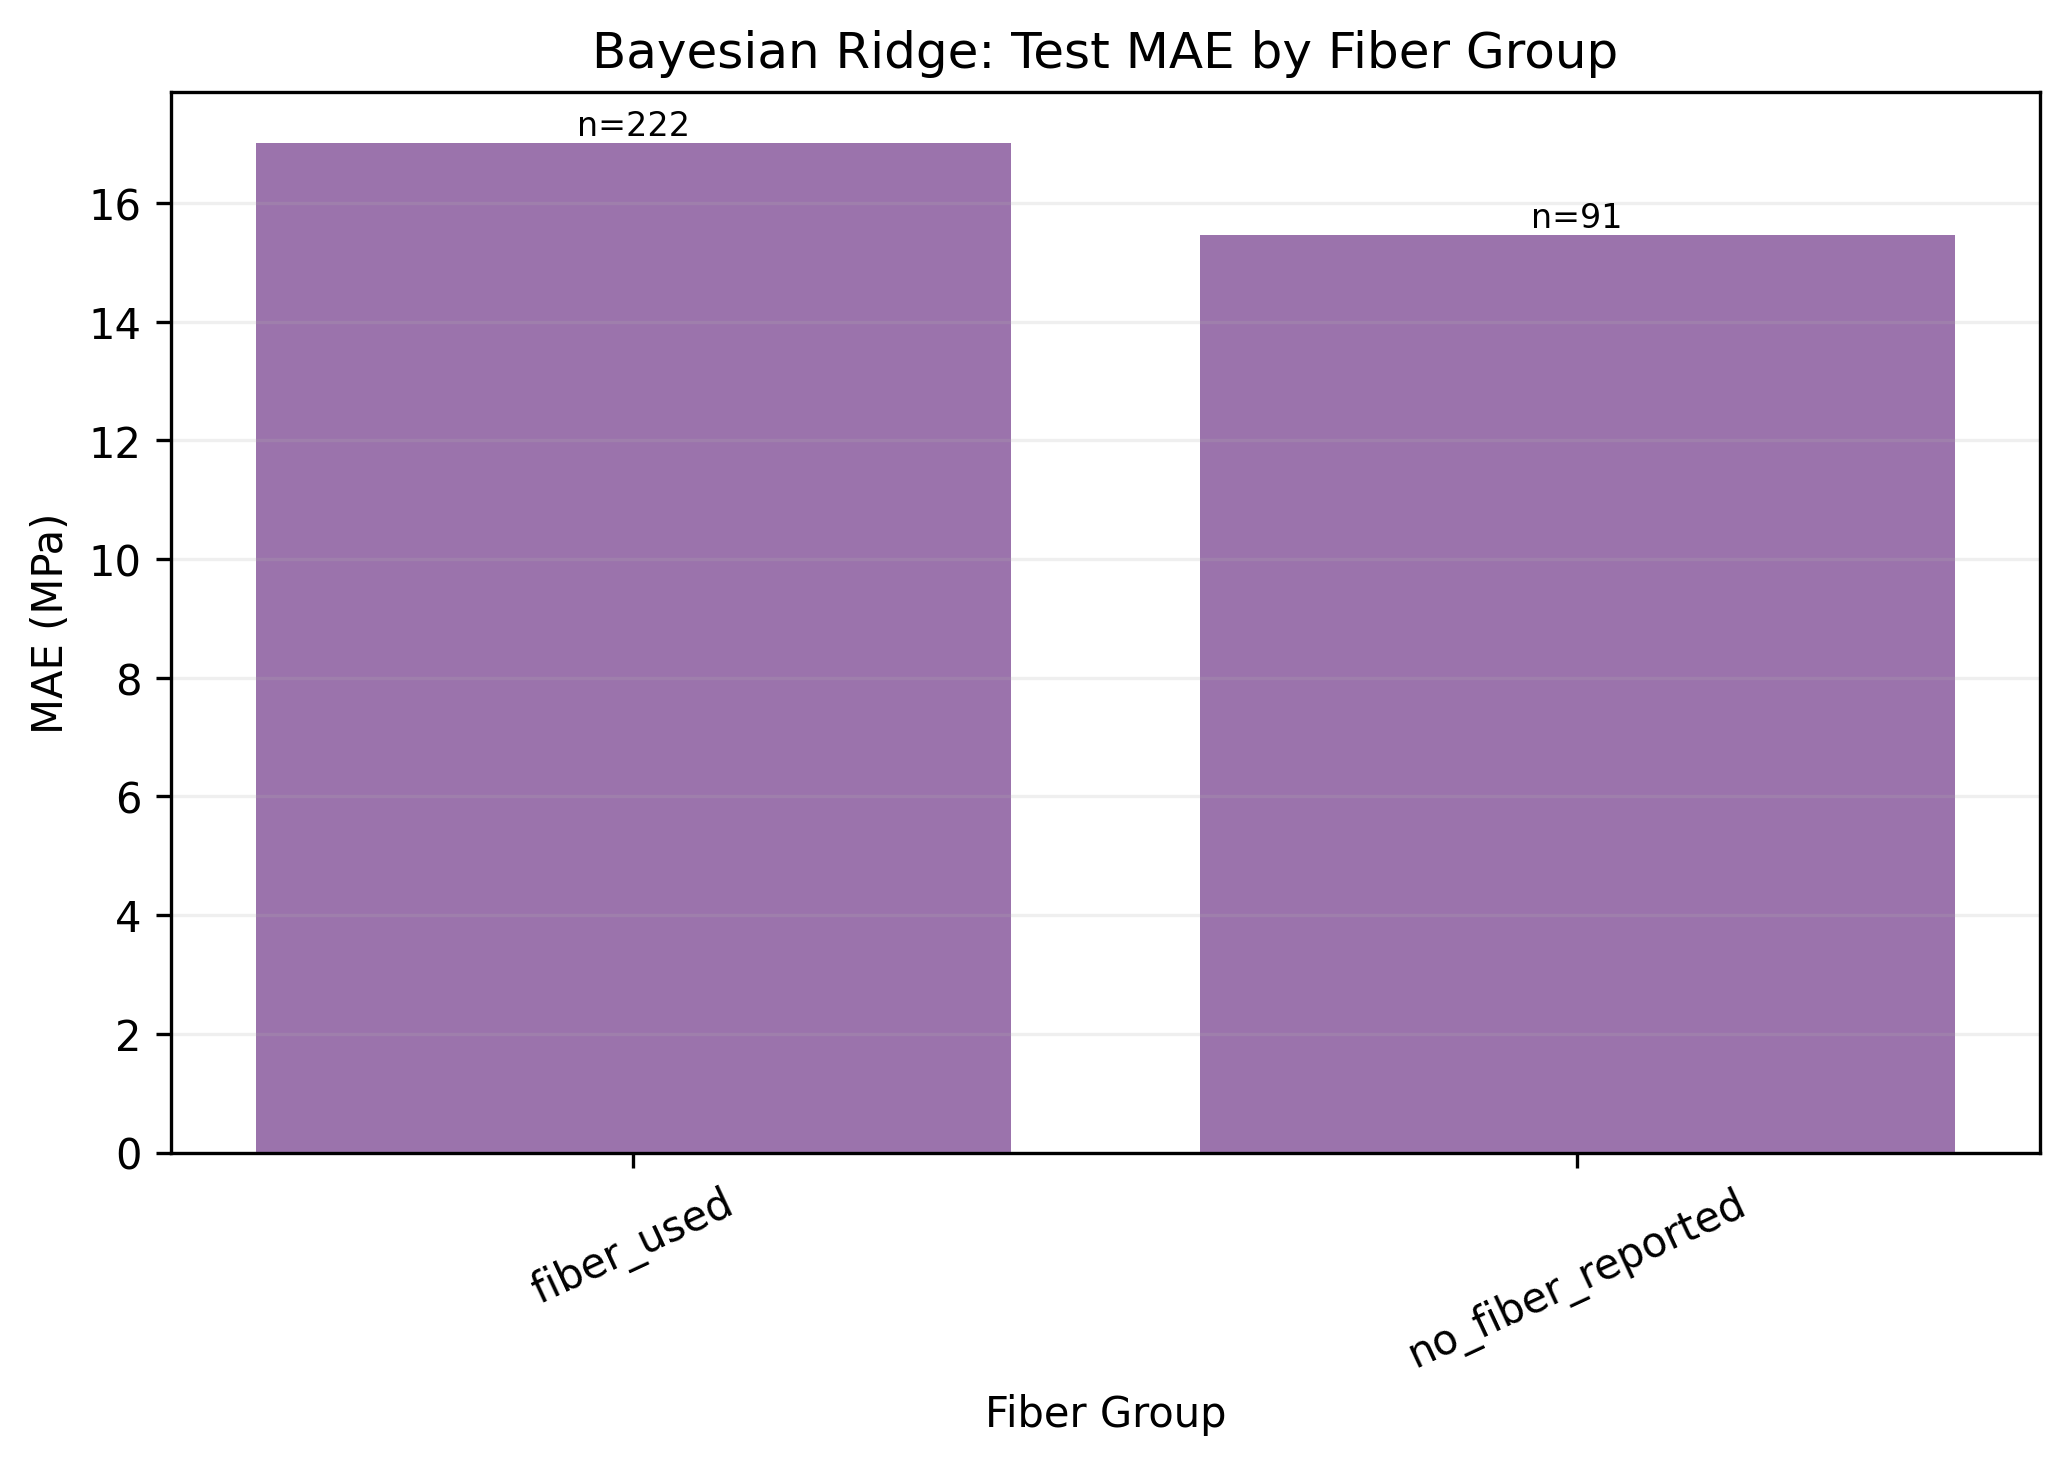

In [8]:
strength_error = load_table("week07_best_model_error_by_strength.csv")
curing_error = load_table("week07_best_model_error_by_curing.csv")
fiber_error = load_table("week07_best_model_error_by_fiber.csv")

display(rounded(strength_error))
show_figure("week07_error_by_strength_bin.png", width=850)
display(rounded(curing_error))
show_figure("week07_error_by_curing_group.png", width=900)
display(rounded(fiber_error))
show_figure("week07_error_by_fiber_group.png", width=850)

## 8. Targeted Experiments

The targeted Week 7 experiments ask three practical questions:

- Do fiber columns carry useful information?
- Does removing target outliers from training help or hurt?
- Do exploratory engineering ratio features improve the shared representation?

All experiments use the same train/validation/test rows and fit preprocessing only on training rows.

,model,delta_MAE,delta_RMSE,delta_R2
3,Polynomial Ridge,4.246,4.853,-0.123
0,Bayesian Ridge,2.701,3.035,-0.097
1,Elastic Net,2.696,3.029,-0.096
2,OLS,2.659,2.997,-0.096


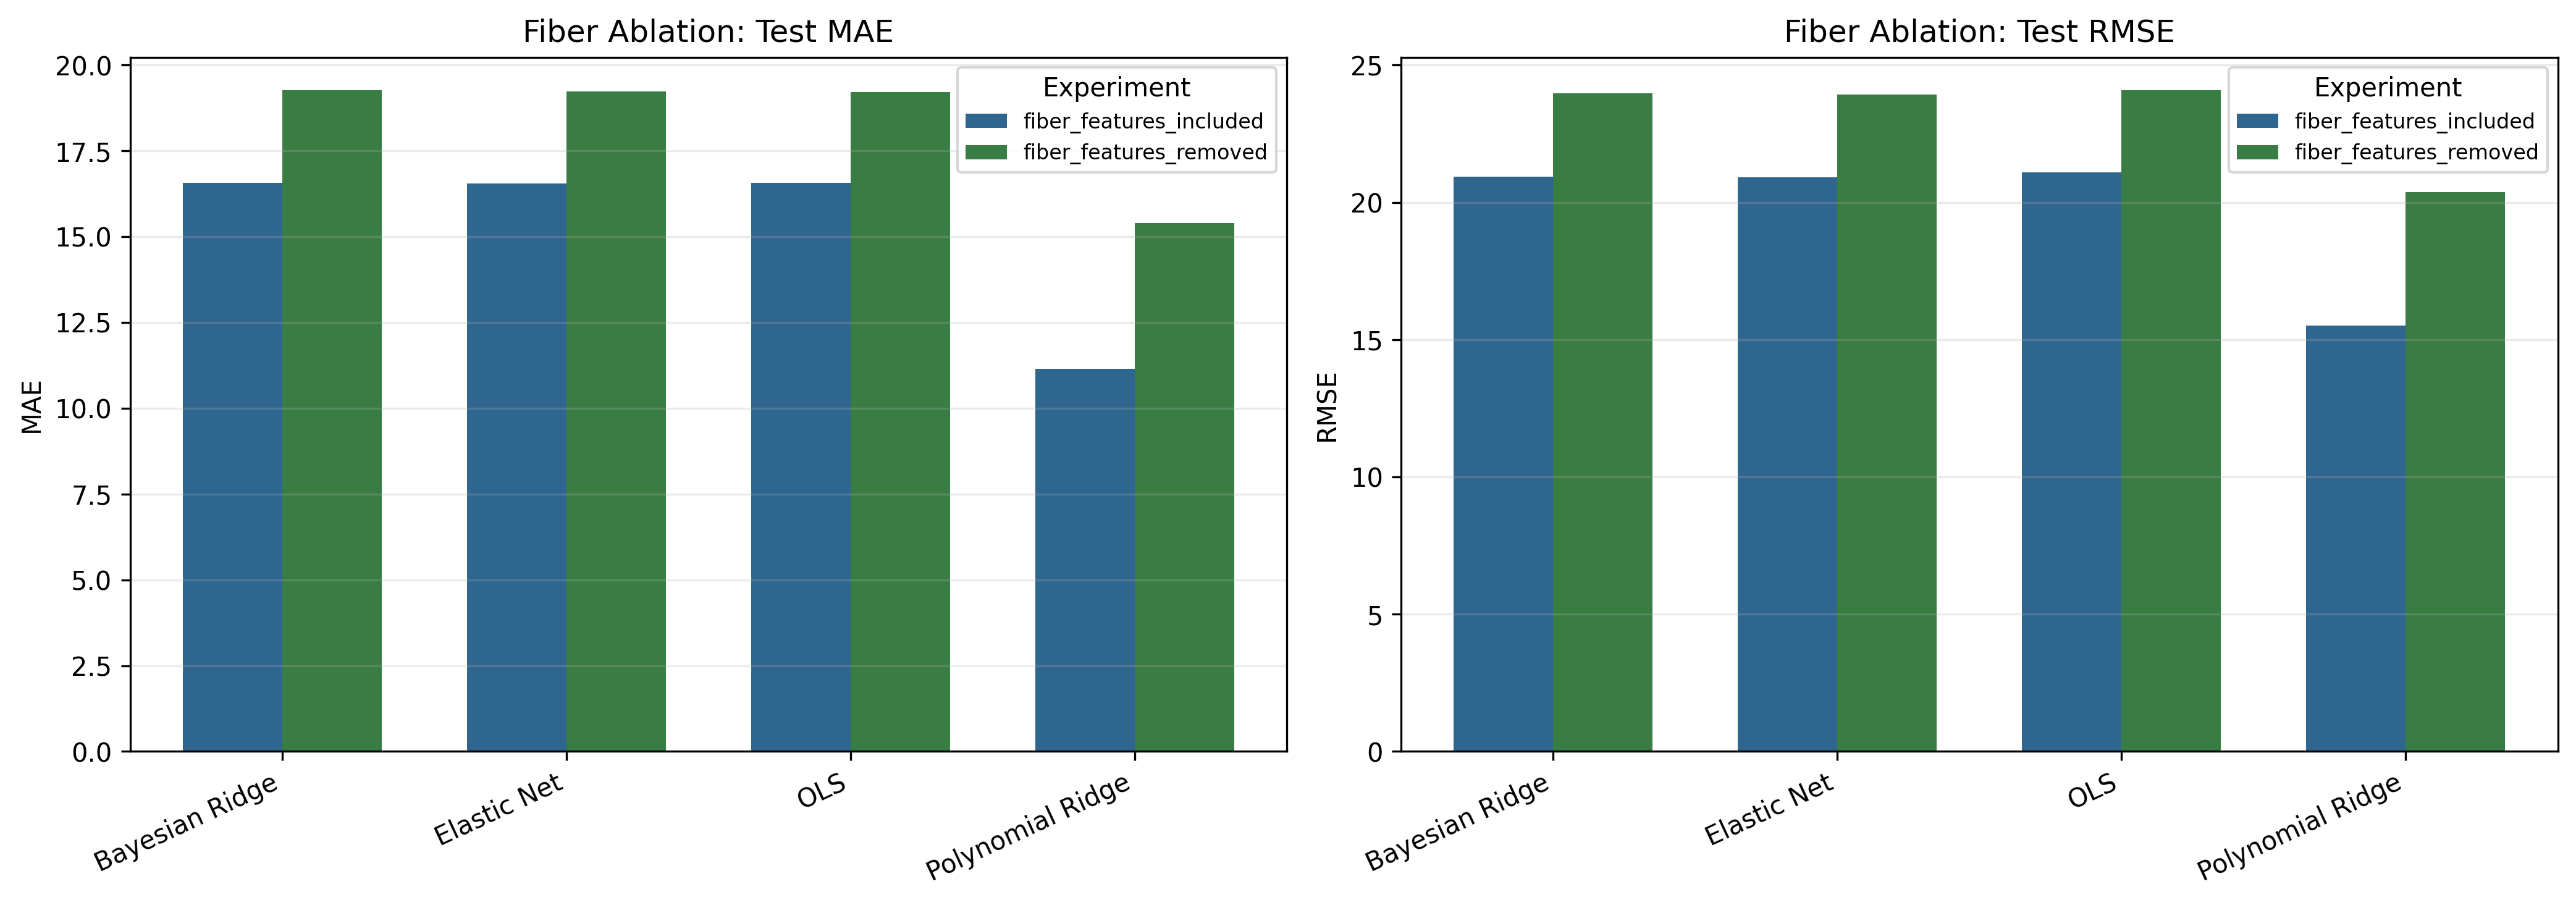

,model,delta_MAE,delta_RMSE,delta_R2
0,Bayesian Ridge,0.833,1.709,-0.053
1,Elastic Net,0.701,1.441,-0.044
2,OLS,0.679,1.319,-0.041
3,Polynomial Ridge,0.649,0.939,-0.021


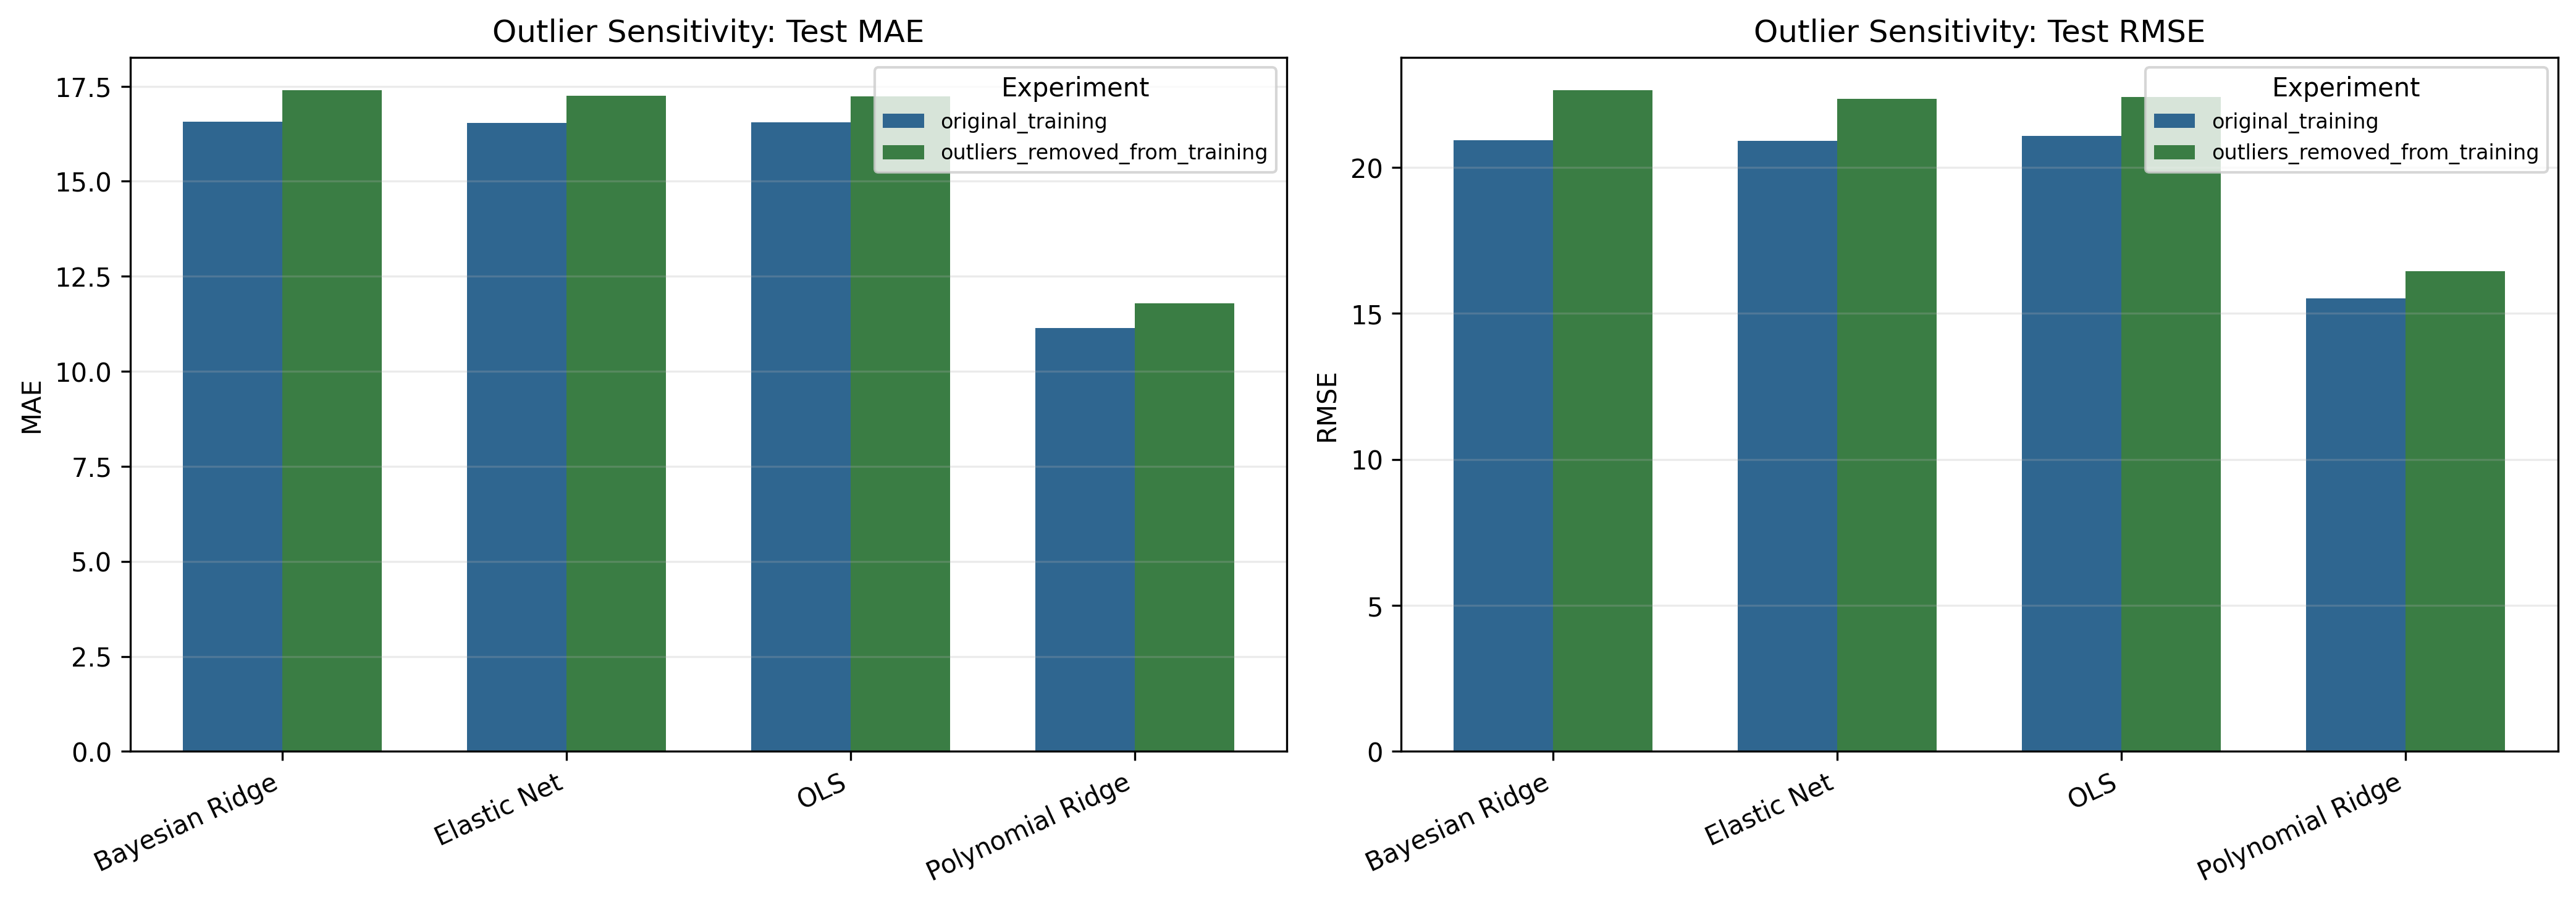

,model,delta_MAE,delta_RMSE,delta_R2
3,Polynomial Ridge,2.081,2.630,-0.063
1,Elastic Net,0.299,0.485,-0.015
2,OLS,0.169,0.481,-0.015
0,Bayesian Ridge,0.311,0.471,-0.014


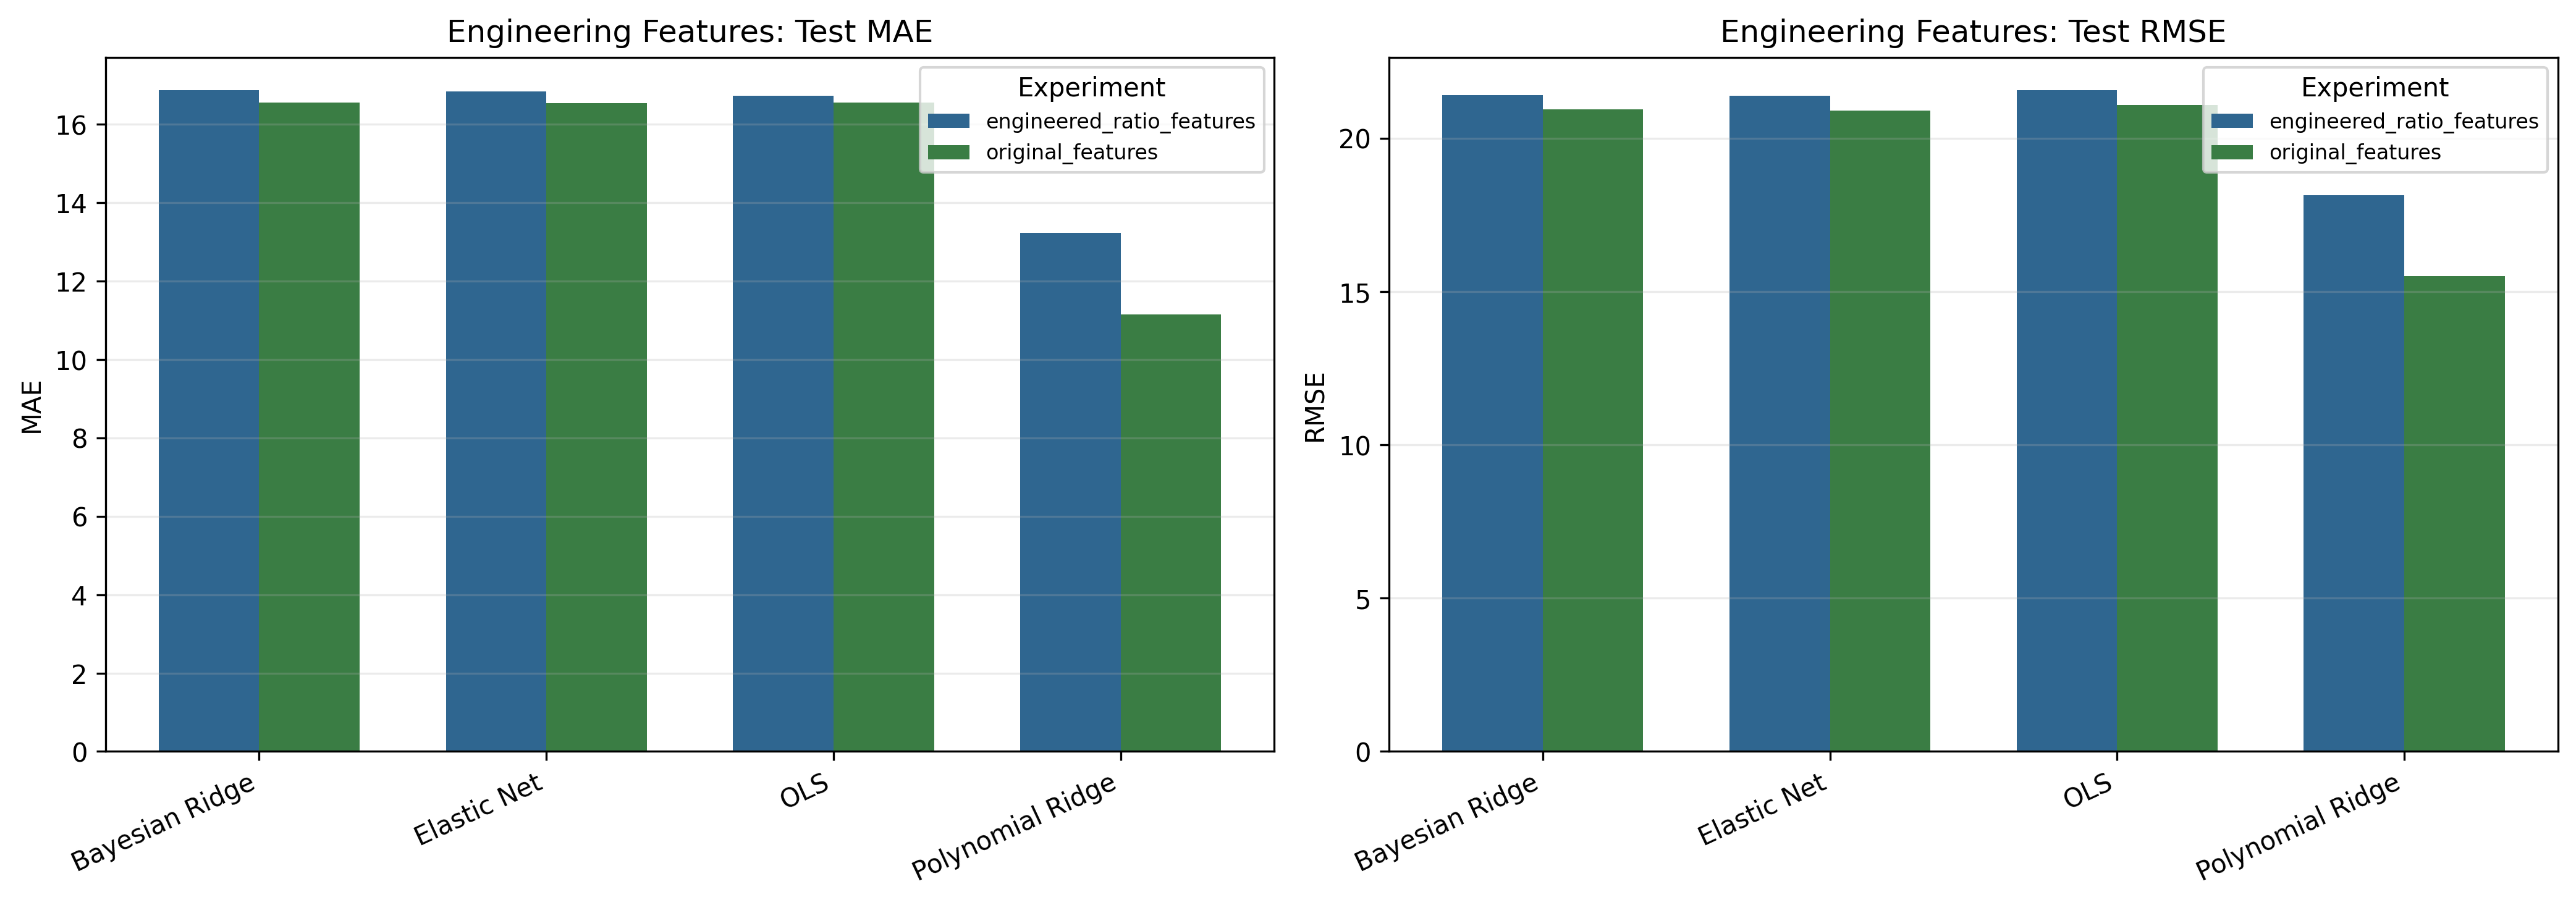

In [9]:
experiment_metrics = load_table("week07_targeted_experiment_metrics.csv")


def experiment_delta(family: str, reference: str, challenger: str) -> pd.DataFrame:
    test = experiment_metrics.query("split == 'test' and experiment_family == @family")
    wide = test.pivot_table(index="model", columns="experiment", values=["MAE", "RMSE", "R2"], aggfunc="mean")
    return pd.DataFrame({
        "model": wide.index,
        "delta_MAE": wide[("MAE", challenger)] - wide[("MAE", reference)],
        "delta_RMSE": wide[("RMSE", challenger)] - wide[("RMSE", reference)],
        "delta_R2": wide[("R2", challenger)] - wide[("R2", reference)],
    }).reset_index(drop=True).sort_values("delta_RMSE", ascending=False)

fiber_delta = experiment_delta("fiber_ablation", "fiber_features_included", "fiber_features_removed")
outlier_delta = experiment_delta("outlier_sensitivity", "original_training", "outliers_removed_from_training")
engineering_delta = experiment_delta("engineering_features", "original_features", "engineered_ratio_features")

display(rounded(fiber_delta))
show_figure("week07_fiber_ablation_comparison.png", width=1100)
display(rounded(outlier_delta))
show_figure("week07_outlier_sensitivity_comparison.png", width=1100)
display(rounded(engineering_delta))
show_figure("week07_engineering_features_comparison.png", width=1100)

### Experiment Interpretation

- Removing fiber features worsens test RMSE by about **3.00 to 4.85 MPa**, depending on the model. Fiber information should stay in the shared feature set.
- Removing target outliers from training worsens test RMSE by about **0.94 to 1.71 MPa**. The extreme strengths appear to contain useful signal rather than pure noise.
- The first engineering-ratio feature set worsens test RMSE by about **0.47 to 2.63 MPa**. This does not mean engineering features are useless; it means this first ratio design is exploratory and not better than the shared semantic representation yet.

## 9. Coefficient Diagnostic

Coefficient plots are useful for interpretation, but they are not causal evidence. Coefficients depend on scaling, encoding, target-encoding behavior, and correlated dataset structure.

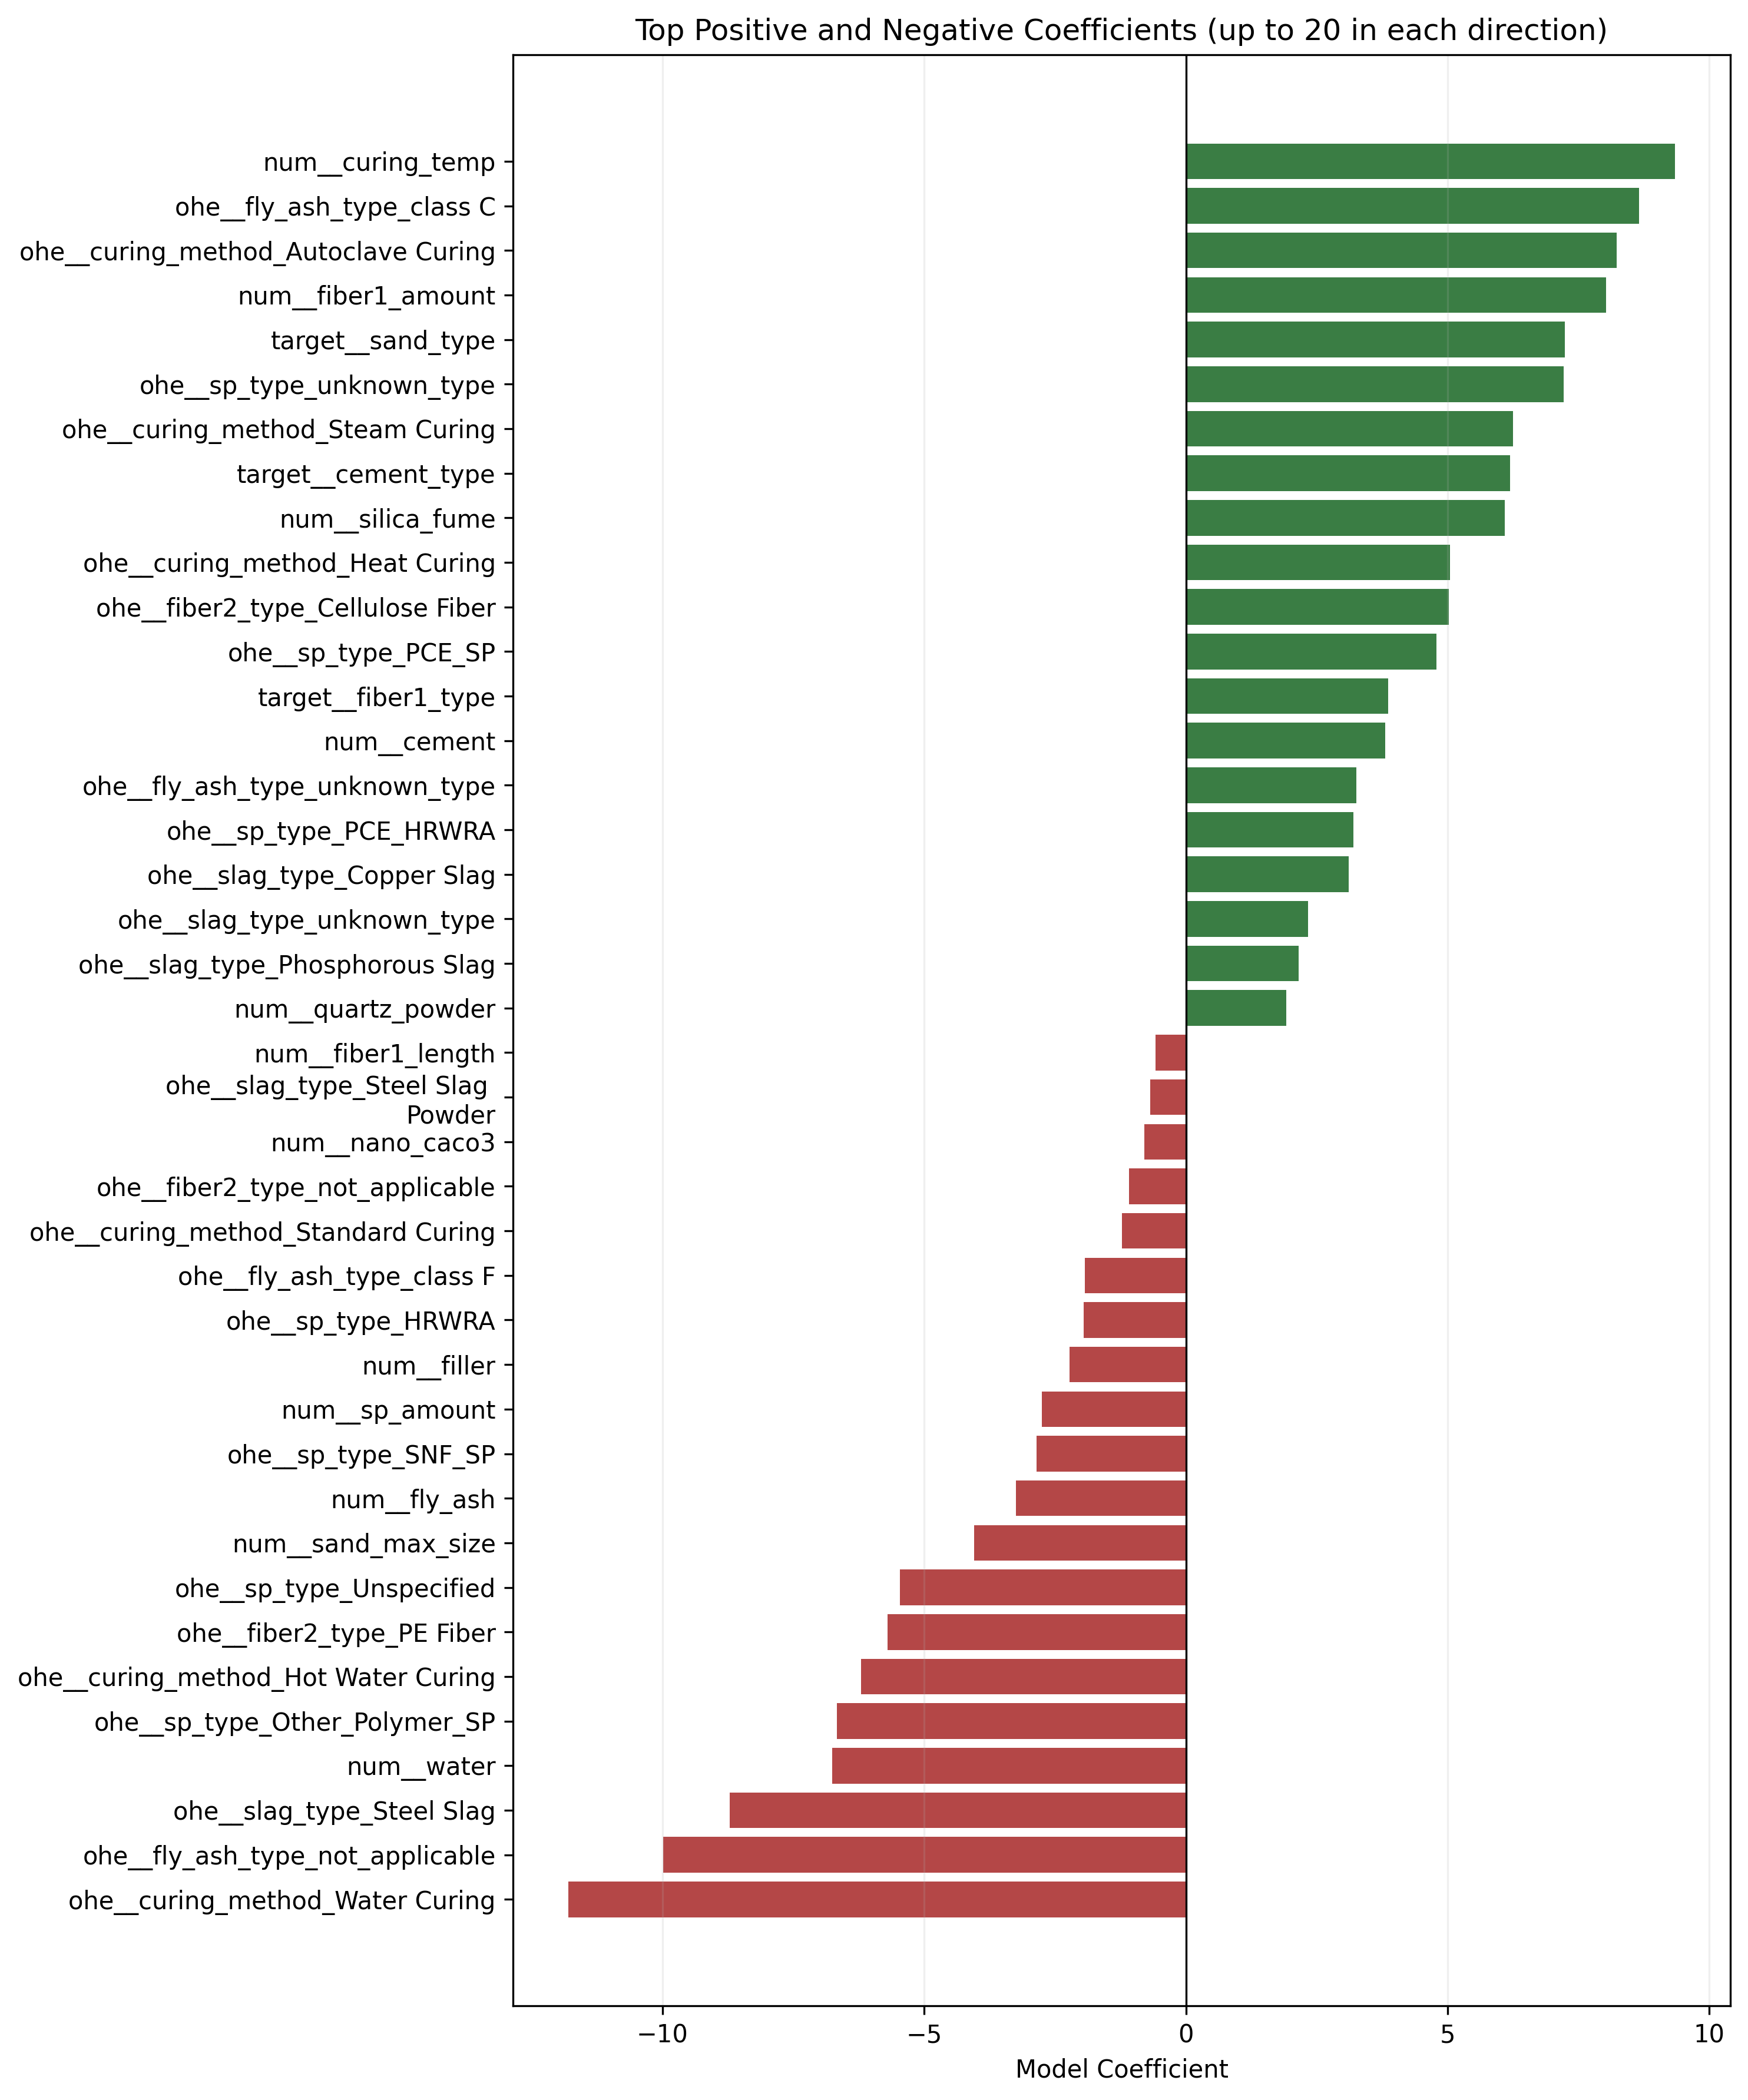

In [10]:
show_figure("week07_selected_baseline_coefficients.png", width=900)

## Final Week 7 Conclusions

The corrected Week 7 setup now uses the shared semantic-recoded 50% dataset and the agreed 60-column preprocessing contract. The selected Linear Family baseline is Bayesian Ridge, with useful but imperfect test performance. Errors remain subgroup-dependent, fiber features are important, target outlier trimming hurts, and the first engineering-ratio experiment is not yet beneficial.

Most importantly, the Week 7 outputs are now comparable because the same shared preprocessing strategy is used from this point onward.